In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print("📁", root)
    for f in files:
        print("   📄", f)

📁 /kaggle/input
📁 /kaggle/input/datasets
📁 /kaggle/input/datasets/muhammadtaaha12
📁 /kaggle/input/datasets/muhammadtaaha12/cve-fix-rag
   📄 final_dataset.jsonl
📁 /kaggle/input/datasets/muhammadtaaha12/cleaned-data
   📄 cleaned_vulnerability_dataset.csv


In [3]:
# !pip install sentence-transformers faiss-cpu

In [4]:
import numpy as np 
import pandas as pd 
import sklearn 

## loading the dataset 

In [5]:
import json

data = []
with open("/kaggle/input/datasets/muhammadtaaha12/cve-fix-rag/final_dataset.jsonl") as f:
    for line in f:
        data.append(json.loads(line))

print("Loaded samples:", len(data))
print(data[0])  # sanity check

KeyboardInterrupt: 

In [ ]:
df = pd.DataFrame(data)

In [ ]:
df

In [ ]:
df.head()

In [ ]:
import torch
print(torch.cuda.is_available())

## making the embeddings to just have a test then we will make the embeddings of whole data

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch sees CUDA: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"Model will run on: {device}")

model = SentenceTransformer("BAAI/bge-large-en-v1.5", device=device)
print(f"Model is on: {model.device}")

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SentenceTransformer("BAAI/bge-large-en-v1.5", device=device)
texts = [
    d["vulnerable_code"] + "\n" + d["fixed_code"]
    for d in data[:2000]
]

print("Texts created:", len(texts))
print(texts[0])
embeddings = model.encode(
    texts,
    batch_size=128,   # increase for GPU
    show_progress_bar=True,
    convert_to_tensor=True,
    normalize_embeddings=True
)

embeddings = embeddings.cpu().numpy()

## the t-sne plot for checking the higher dimension

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("BAAI/bge-large-en")

# ⚠️ Always limit samples (VERY IMPORTANT)
X = np.array(embeddings[:2000])

# ✅ t-SNE works better after normalization
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

# ✅ Run t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    init="pca"
)

reduced = tsne.fit_transform(X)

# ✅ Plot
plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], s=5)
plt.title("t-SNE Visualization of Code Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [ ]:
# Number of samples you used for t‑SNE (2000)
n_samples = 2000

# Get the first n_samples patterns (labels)
labels = df["pattern"].iloc[:n_samples].values

In [ ]:
unique_patterns = np.unique(labels)
pattern_to_num = {p: i for i, p in enumerate(unique_patterns)}
color_codes = np.array([pattern_to_num[p] for p in labels])

In [ ]:
X = np.array(embeddings[:n_samples])   # shape (2000, embedding_dim)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# t‑SNE (you already have this)
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init="pca")
reduced = tsne.fit_transform(X)

# Create a figure
plt.figure(figsize=(10, 8))
sc = plt.scatter(reduced[:, 0], reduced[:, 1], c=color_codes, cmap='tab10', s=5, alpha=0.7)

# Add a legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc.cmap(sc.norm(i)), markersize=8)
           for i in range(len(unique_patterns))]
plt.legend(handles, unique_patterns, title="Vulnerability Pattern", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("t‑SNE Visualization of Code Embeddings (colored by vulnerability pattern)")
plt.xlabel("t‑SNE dimension 1")
plt.ylabel("t‑SNE dimension 2")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler   # optional, but can keep

# -----------------------------------------------------------------
# 1. Prepare data (assuming df is your DataFrame and embeddings already computed)
# -----------------------------------------------------------------
n_samples = 2000   # must match the number of embeddings you use
X = np.array(embeddings[:n_samples])   # shape (2000, embedding_dim)

# (Optional) If you want to keep StandardScaler – but with normalized embeddings it's not necessary)
# X = StandardScaler().fit_transform(X)

# -----------------------------------------------------------------
# 2. Extract labels for the first n_samples
# -----------------------------------------------------------------
labels_pattern = df["pattern"].iloc[:n_samples].values
labels_language = df["language"].iloc[:n_samples].values

# -----------------------------------------------------------------
# 3. Convert to numeric codes for coloring
# -----------------------------------------------------------------
unique_patterns = np.unique(labels_pattern)
pattern_to_num = {p: i for i, p in enumerate(unique_patterns)}
color_codes_pattern = np.array([pattern_to_num[p] for p in labels_pattern])

unique_langs = np.unique(labels_language)
lang_to_num = {l: i for i, l in enumerate(unique_langs)}
color_codes_lang = np.array([lang_to_num[l] for l in labels_language])

# -----------------------------------------------------------------
# 4. Run t-SNE (once, reuse the same reduced coordinates for both plots)
# -----------------------------------------------------------------
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init="pca")
reduced = tsne.fit_transform(X)

# -----------------------------------------------------------------
# 5. Create subplots
# -----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: colored by pattern ----
sc1 = ax1.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_pattern, cmap='tab10', s=5, alpha=0.7)
ax1.set_title("By Vulnerability Pattern")
# Build legend handles for patterns
handles_pattern = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc1.cmap(sc1.norm(i)), markersize=8)
                   for i in range(len(unique_patterns))]
ax1.legend(handles_pattern, unique_patterns, title="Pattern", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

# ---- Plot 2: colored by language ----
sc2 = ax2.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_lang, cmap='Set1', s=5, alpha=0.7)
ax2.set_title("By Programming Language")
handles_lang = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc2.cmap(sc2.norm(i)), markersize=8)
                for i in range(len(unique_langs))]
ax2.legend(handles_lang, unique_langs, title="Language", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## using the guess lang for controlling the hallucination for making the fix

In [ ]:
# Cell 1: Install pygments (if not already installed)
!pip install -q pygments

In [ ]:
# Cell 2: Fill missing languages
import pandas as pd
from pygments.lexers import guess_lexer
from pygments.util import ClassNotFound
from tqdm import tqdm

# Make a copy or work on original df
df = df.copy()  # replace 'df' with your actual DataFrame variable name

def detect_language_from_code(code: str) -> str:
    """Return language name or 'unknown' if detection fails."""
    if not isinstance(code, str) or len(code.strip()) < 20:
        return 'unknown'
    try:
        lexer = guess_lexer(code)
        # Lexer name examples: 'Python', 'Java', 'C++', 'JavaScript'
        return lexer.name
    except ClassNotFound:
        return 'unknown'

# Apply only to rows where language is missing or 'unknown'
mask = (df['language'].isna()) | (df['language'].str.lower() == 'unknown')
rows_to_fix = df[mask]

print(f"Found {len(rows_to_fix)} rows with missing/unknown language. Detecting...")

# Try fixed_code first, then vulnerable_code
detected_langs = []
for idx, row in tqdm(rows_to_fix.iterrows(), total=len(rows_to_fix), desc="Detecting language"):
    code = row.get('fixed_code', '')
    if not isinstance(code, str) or len(code.strip()) < 20:
        code = row.get('vulnerable_code', '')
    lang = detect_language_from_code(code)
    detected_langs.append(lang)

# Assign back
df.loc[mask, 'language'] = detected_langs

# Show summary
print("\nLanguage distribution after fixing:")
print(df['language'].value_counts())
print(f"\nRemaining 'unknown': {(df['language'] == 'unknown').sum()}")

## the sub plot after the fix 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler   # optional, but can keep

# -----------------------------------------------------------------
# 1. Prepare data (assuming df is your DataFrame and embeddings already computed)
# -----------------------------------------------------------------
n_samples = 2000   # must match the number of embeddings you use
X = np.array(embeddings[:n_samples])   # shape (2000, embedding_dim)

# (Optional) If you want to keep StandardScaler – but with normalized embeddings it's not necessary)
# X = StandardScaler().fit_transform(X)

# -----------------------------------------------------------------
# 2. Extract labels for the first n_samples
# -----------------------------------------------------------------
labels_pattern = df["pattern"].iloc[:n_samples].values
labels_language = df["language"].iloc[:n_samples].values

# -----------------------------------------------------------------
# 3. Convert to numeric codes for coloring
# -----------------------------------------------------------------
unique_patterns = np.unique(labels_pattern)
pattern_to_num = {p: i for i, p in enumerate(unique_patterns)}
color_codes_pattern = np.array([pattern_to_num[p] for p in labels_pattern])

unique_langs = np.unique(labels_language)
lang_to_num = {l: i for i, l in enumerate(unique_langs)}
color_codes_lang = np.array([lang_to_num[l] for l in labels_language])

# -----------------------------------------------------------------
# 4. Run t-SNE (once, reuse the same reduced coordinates for both plots)
# -----------------------------------------------------------------
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init="pca")
reduced = tsne.fit_transform(X)

# -----------------------------------------------------------------
# 5. Create subplots
# -----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: colored by pattern ----
sc1 = ax1.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_pattern, cmap='tab10', s=5, alpha=0.7)
ax1.set_title("By Vulnerability Pattern")
# Build legend handles for patterns
handles_pattern = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc1.cmap(sc1.norm(i)), markersize=8)
                   for i in range(len(unique_patterns))]
ax1.legend(handles_pattern, unique_patterns, title="Pattern", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

# ---- Plot 2: colored by language ----
sc2 = ax2.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_lang, cmap='Set1', s=5, alpha=0.7)
ax2.set_title("By Programming Language")
handles_lang = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc2.cmap(sc2.norm(i)), markersize=8)
                for i in range(len(unique_langs))]
ax2.legend(handles_lang, unique_langs, title="Language", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## making the fix for the unclassified vernulbilities 

## using the pre-tuned code bert model for making the labels of the embeddings 

In [ ]:
import torch
import re
import json
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from huggingface_hub import hf_hub_download
import pandas as pd
from tqdm import tqdm

# ---------- 1. Load model and real CWE labels ----------
torch.set_default_device('cpu')
model_name = "Dunateo/roberta-cwe-classifier-kelemia-v0.2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Load real label dictionary
label_dict_path = hf_hub_download(repo_id=model_name, filename="label_dict.json")
with open(label_dict_path, "r") as f:
    label_dict = json.load(f)          # {"CWE-20: Improper Input Validation": 0, ...}
idx_to_full_label = {v: k for k, v in label_dict.items()}
model.config.id2label = idx_to_full_label

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

def extract_cwe_id(full_label: str) -> str:
    match = re.match(r'(CWE-\d+)', full_label)
    return match.group(1) if match else full_label

def get_cwe_and_description(code: str):
    if not isinstance(code, str) or len(code.strip()) < 20:
        return ("SHORT", "Code too short")
    inputs = tokenizer(code, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        pred_idx = model(**inputs).logits.argmax(dim=-1).item()
    full = model.config.id2label[pred_idx]   # e.g., "CWE-89: SQL Injection"
    cwe = extract_cwe_id(full)
    return (cwe, full)

# ---------- 2. Collect unique CWE predictions from your 'general' rows ----------
# If you already have 'misc' rows with LABEL_X, we can also process them.
# For clarity, let's re‑process all rows that are not yet assigned a high‑level category.
target_mask = df['pattern'].isin(['general', 'misc']) | df['pattern'].str.startswith('LABEL_', na=False)
rows_to_classify = df[target_mask].copy()
print(f"Found {len(rows_to_classify)} rows to classify.")

cwe_counter = {}
cwe_descriptions = {}
codes_to_use = rows_to_classify['fixed_code'].fillna(rows_to_classify['vulnerable_code'])

for code in tqdm(codes_to_use, desc="Classifying"):
    cwe, desc = get_cwe_and_description(code)
    cwe_counter[cwe] = cwe_counter.get(cwe, 0) + 1
    if cwe not in cwe_descriptions:
        cwe_descriptions[cwe] = desc

# ---------- 3. Show top CWE IDs and their descriptions ----------
print("\n🔍 Top 20 CWE IDs found in your data:")
sorted_cwes = sorted(cwe_counter.items(), key=lambda x: x[1], reverse=True)[:20]
for cwe, cnt in sorted_cwes:
    desc = cwe_descriptions.get(cwe, "No description")
    print(f"{cwe:8} ({cnt:5} rows) → {desc}")

# ---------- 4. Build mapping from CWE to your high‑level categories ----------
# You already have a partial mapping; let's extend it based on the top CWEs above.
# We'll create a new dictionary and you can manually add entries.
print("\n📝 Now, create a mapping from CWE to your categories.")
print("Your existing categories: injection, xss, auth, file, crypto, deserialization, data_exposure, business_logic, config, command_injection, sql_injection, etc.")

# Start with your existing mapping
cwe_to_category = {
    "CWE-89": "sql_injection",
    "CWE-77": "command_injection",
    "CWE-78": "command_injection",
    "CWE-20": "injection",
    "CWE-74": "injection",
    "CWE-79": "xss",
    "CWE-287": "auth",
    "CWE-306": "auth",
    "CWE-862": "auth",
    "CWE-732": "auth",
    "CWE-22": "file",
    "CWE-434": "file",
    "CWE-73": "file",
    "CWE-798": "crypto",
    "CWE-327": "crypto",
    "CWE-326": "crypto",
    "CWE-502": "deserialization",
    "CWE-119": "injection",
    "CWE-125": "injection",
    "CWE-190": "injection",
    "CWE-787": "injection",
    "CWE-416": "file",
    "CWE-476": "file",
    "CWE-200": "data_exposure",
    "CWE-201": "data_exposure",
    "CWE-840": "business_logic",
    "CWE-15": "config",
    "CWE-16": "config",
}

# Now manually add missing mappings for the top CWEs you saw.
# For example, if you see CWE-416 (Use After Free) you might map to "memory" or "file".
# I'll add some plausible defaults; you can change them.
# Add these mappings to your cwe_to_category dictionary
additional_mappings = {
    "CWE-617": "resource",      # Reachable Assertion → resource exhaustion
    "CWE-601": "auth",          # URL Redirection to Untrusted Site (Open Redirect)
    "CWE-295": "crypto",        # Improper Certificate Validation
    "CWE-611": "injection",     # Improper Restriction of XML External Entity Reference (XXE)
    "CWE-400": "resource",      # Uncontrolled Resource Consumption
    "CWE-134": "injection",     # Use of Externally-Controlled Format String
    "CWE-269": "auth",          # Improper Privilege Management
    "CWE-369": "resource",      # Divide By Zero
    "CWE-755": "error",         # Improper Handling of Exceptional Conditions
    "CWE-59": "file",           # Improper Link Resolution Before File Access
    "CWE-835": "resource",      # Loop with Unreachable Exit Condition (Infinite Loop)
    "CWE-120": "injection",     # Buffer Copy without Checking Size (classic overflow)
    "CWE-754": "error",         # Improper Check for Unusual Conditions
    "CWE-863": "auth",          # Incorrect Authorization
    "CWE-347": "crypto",        # Improper Verification of Cryptographic Signature
    "CWE-276": "auth",          # Incorrect Default Permissions
    "CWE-915": "injection",     # Improperly Controlled Modification of Dynamically-Determined Object Attributes
    "CWE-674": "resource",      # Uncontrolled Recursion
    "CWE-129": "injection",     # Improper Validation of Array Index
    "CWE-330": "crypto",        # Use of Insufficiently Random Values
    "CWE-704": "error",         # Incorrect Type Conversion
    "CWE-191": "injection",     # Integer Underflow
    "CWE-362": "file",          # Concurrent Execution using Shared Resource (Race Condition)
    "CWE-908": "error",         # Use of Uninitialized Resource
    "CWE-770": "resource",      # Allocation of Resources Without Limits
    "CWE-843": "error",         # Access of Resource Using Incompatible Type
    "CWE-918": "injection",     # Server-Side Request Forgery (SSRF)
    "CWE-203": "data_exposure", # Observable Discrepancy
    "CWE-401": "resource",      # Improper Release of Memory Before Reuse (Memory Leak)
    "CWE-665": "config",        # Improper Initialization
    "CWE-444": "network",       # Inconsistent Interpretation of HTTP Requests
    "CWE-532": "data_exposure", # Insertion of Sensitive Information into Log File
    "CWE-319": "network",       # Cleartext Transmission of Sensitive Information
    "CWE-415": "memory",        # Double Free
    "CWE-427": "file",          # Uncontrolled Search Path Element
    "CWE-522": "crypto",        # Insufficiently Protected Credentials
    "CWE-384": "auth",          # Session Fixation
    "CWE-1236": "injection",    # Improper Neutralization of Formula Elements in a CSV File
    "CWE-613": "auth",          # Insufficient Session Expiration
    "CWE-668": "data_exposure", # Exposure of Resource to Wrong Sphere
    "CWE-1021": "auth",         # Improper Restriction of Rendered UI Layers
    "CWE-345": "crypto",        # Insufficient Verification of Data Authenticity
    "CWE-307": "auth",          # Improper Restriction of Excessive Authentication Attempts
    "CWE-824": "error",         # Access of Uninitialized Pointer
    "CWE-772": "resource",      # Missing Release of Resource
    "CWE-193": "error",         # Off-by-one Error
    "CWE-426": "file",          # Untrusted Search Path
    "CWE-284": "auth",          # Improper Access Control
    "CWE-346": "auth",          # Origin Validation Error
}
cwe_to_category.update(additional_mappings)


# For any CWE not in the dictionary, we will keep the CWE ID itself (or you can keep as 'misc')
def map_cwe_to_category(cwe: str) -> str:
    return cwe_to_category.get(cwe, cwe)   # returns CWE ID if not mapped, e.g., "CWE-123"

# ---------- 5. Apply mapping to all rows ----------
# First, get the predicted CWE for each row that needs updating
predicted_cwes = []
for code in tqdm(codes_to_use, desc="Getting CWE predictions"):
    cwe, _ = get_cwe_and_description(code)
    predicted_cwes.append(cwe)

# Update the dataframe
df.loc[target_mask, 'pattern'] = [map_cwe_to_category(cwe) for cwe in predicted_cwes]

# ---------- 6. Show final distribution ----------
print("\n✅ Final distribution of high‑level categories:")
print(df['pattern'].value_counts())
print(f"\nRows still with 'general' or 'misc': {(df['pattern'].isin(['general','misc'])).sum()}")

In [ ]:
 #Re‑apply mapping to all rows that are still raw CWE IDs (i.e., start with 'CWE-')
mask = df['pattern'].str.startswith('CWE-', na=False)
df.loc[mask, 'pattern'] = df.loc[mask, 'pattern'].apply(lambda c: cwe_to_category.get(c, c))

# Show final distribution again
print(df['pattern'].value_counts())

In [ ]:
def strict_map(cwe):
    known = {"injection","file","xss","auth","sql_injection","command_injection","crypto","deserialization","data_exposure","business_logic","config"}
    cat = cwe_to_category.get(cwe, "other")
    return cat if cat in known else "other"

## Again doing the pair plot 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler   # optional, but can keep

# -----------------------------------------------------------------
# 1. Prepare data (assuming df is your DataFrame and embeddings already computed)
# -----------------------------------------------------------------
n_samples = 2000   # must match the number of embeddings you use
X = np.array(embeddings[:n_samples])   # shape (2000, embedding_dim)

# (Optional) If you want to keep StandardScaler – but with normalized embeddings it's not necessary)
# X = StandardScaler().fit_transform(X)

# -----------------------------------------------------------------
# 2. Extract labels for the first n_samples
# -----------------------------------------------------------------
labels_pattern = df["pattern"].iloc[:n_samples].values
labels_language = df["language"].iloc[:n_samples].values

# -----------------------------------------------------------------
# 3. Convert to numeric codes for coloring
# -----------------------------------------------------------------
unique_patterns = np.unique(labels_pattern)
pattern_to_num = {p: i for i, p in enumerate(unique_patterns)}
color_codes_pattern = np.array([pattern_to_num[p] for p in labels_pattern])

unique_langs = np.unique(labels_language)
lang_to_num = {l: i for i, l in enumerate(unique_langs)}
color_codes_lang = np.array([lang_to_num[l] for l in labels_language])

# -----------------------------------------------------------------
# 4. Run t-SNE (once, reuse the same reduced coordinates for both plots)
# -----------------------------------------------------------------
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init="pca")
reduced = tsne.fit_transform(X)

# -----------------------------------------------------------------
# 5. Create subplots
# -----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: colored by pattern ----
sc1 = ax1.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_pattern, cmap='tab10', s=5, alpha=0.7)
ax1.set_title("By Vulnerability Pattern")
# Build legend handles for patterns
handles_pattern = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc1.cmap(sc1.norm(i)), markersize=8)
                   for i in range(len(unique_patterns))]
ax1.legend(handles_pattern, unique_patterns, title="Pattern", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

# ---- Plot 2: colored by language ----
sc2 = ax2.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_lang, cmap='Set1', s=5, alpha=0.7)
ax2.set_title("By Programming Language")
handles_lang = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc2.cmap(sc2.norm(i)), markersize=8)
                for i in range(len(unique_langs))]
ax2.legend(handles_lang, unique_langs, title="Language", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Extract the raw CWE IDs for all misc rows


In [ ]:
df.to_csv('cleaned_vulnerability_dataset.csv', index=False)

## Generate embeddings for complete dataset  
- these are generic embeddings can be used by any one 

In [ ]:
texts = [f"{row['vulnerable_code']}\n{row['fixed_code']}" for _, row in df.iterrows()]

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("BAAI/bge-large-en-v1.5", device="cuda")
batch_size = 128

# For large datasets, encode in chunks
all_embeddings = []
for i in range(0, len(texts), batch_size):
    chunk = texts[i:i+batch_size]
    embeddings = model.encode(chunk, convert_to_numpy=True, normalize_embeddings=True)
    all_embeddings.append(embeddings)
    print(f"Processed {min(i+batch_size, len(texts))}/{len(texts)}")

embeddings = np.vstack(all_embeddings)

In [ ]:
import chromadb
from chromadb.utils import embedding_functions

client = chromadb.Client()
collection = client.create_collection(
    name="vuln_fixes",
    embedding_function=embedding_functions.SentenceTransformerEmbeddingFunction(model_name="BAAI/bge-large-en-v1.5")
)

# Add in batches
batch_size = 1000
for i in range(0, len(df), batch_size):
    batch = df.iloc[i:i+batch_size]
    collection.add(
        documents=batch['fixed_code'].tolist(),   # or the combined text
        metadatas=batch[['pattern', 'language']].to_dict(orient='records'),
        ids=[f"id_{j}" for j in range(i, i+len(batch))]
    )

In [ ]:
np.save('embeddings.npy', embeddings)
df.to_parquet('dataset_with_embeddings.parquet', index=False)

## Embeddings for the Sudofix

In [ ]:
data = pd.read_csv("/kaggle/input/datasets/muhammadtaaha12/cleaned-data/cleaned_vulnerability_dataset.csv")

In [ ]:
df = pd.DataFrame(data)

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm import tqdm

# 1. Filter to supported languages
supported_languages = ['c', 'cpp', 'go', 'java', 'javascript', 'python', 'rust']
df_filtered = df[df['language'].str.lower().isin(supported_languages)].copy()
print(f"Filtered to {len(df_filtered)} rows")

# 2. Create texts for embedding
texts = [f"{row['vulnerable_code']}\n{row['fixed_code']}" for _, row in df_filtered.iterrows()]

# 3. Generate embeddings
model = SentenceTransformer("BAAI/bge-large-en-v1.5", device="cuda")
batch_size = 128
all_embeddings = []

for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
    chunk = texts[i:i+batch_size]
    embeddings = model.encode(chunk, convert_to_numpy=True, normalize_embeddings=True)
    all_embeddings.append(embeddings)

embeddings = np.vstack(all_embeddings)
print(f"Embeddings shape: {embeddings.shape}")

# 4. Save filtered dataset with embeddings
df_filtered['embedding'] = embeddings.tolist()
df_filtered.to_parquet('filtered_dataset_with_embeddings.parquet', index=False)

In [ ]:
# Save embeddings as .npy file (binary format, fast to load)
np.save('embeddings.npy', embeddings)

# Save the filtered DataFrame (with metadata) as Parquet (compressed, efficient)
df_filtered.to_parquet('filtered_dataset.parquet', index=False)

# Optionally, save combined file with embeddings as a column (can be large)
df_filtered_with_emb = df_filtered.copy()
df_filtered_with_emb['embedding'] = embeddings.tolist()
df_filtered_with_emb.to_parquet('full_dataset_with_embeddings.parquet', index=False)

print("Saved:")
print("- embeddings.npy (shape: {})".format(embeddings.shape))
print("- filtered_dataset.parquet (metadata only)")
print("- full_dataset_with_embeddings.parquet (metadata + embeddings)")

## interactive 3D plot

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from tqdm import tqdm

# ========== 1. Prepare your embeddings (use filtered dataset) ==========
# Assuming you have df_filtered and embeddings from your filtered dataset
# If not, load them:
# df_filtered = pd.read_parquet('filtered_dataset_with_embeddings.parquet')
# embeddings = np.array(df_filtered['embedding'].tolist())

# For t-SNE, use a sample (3000-5000 points max for performance)
sample_size = min(5000, len(embeddings))
sample_indices = np.random.choice(len(embeddings), sample_size, replace=False)

sample_embeddings = embeddings[sample_indices]
sample_df = df_filtered.iloc[sample_indices].copy()

# ========== 2. Reduce dimensions to 3D ==========
print("Reducing dimensions to 3D...")
# Option A: t-SNE (better for clusters, slower)
# tsne = TSNE(n_components=3, perplexity=30, random_state=42, n_iter=1000)
# reduced = tsne.fit_transform(sample_embeddings)

# Option B: PCA (faster, preserves global structure)
pca = PCA(n_components=3, random_state=42)
reduced = pca.fit_transform(sample_embeddings)

sample_df['x'] = reduced[:, 0]
sample_df['y'] = reduced[:, 1]
sample_df['z'] = reduced[:, 2]

# ========== 3. Create interactive 3D scatter plot ==========
# Color by vulnerability pattern
fig1 = px.scatter_3d(
    sample_df,
    x='x', y='y', z='z',
    color='pattern',
    hover_data=['language', 'pattern', 'file'],
    title='Vulnerability Embeddings - Colored by Pattern',
    opacity=0.7,
    size_max=8,
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig1.update_layout(
    scene=dict(
        xaxis_title='Component 1',
        yaxis_title='Component 2',
        zaxis_title='Component 3',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))
    ),
    height=800,
    width=1200
)

fig1.show()

# ========== 4. Second plot: Color by programming language ==========
fig2 = px.scatter_3d(
    sample_df,
    x='x', y='y', z='z',
    color='language',
    hover_data=['pattern', 'language', 'file'],
    title='Vulnerability Embeddings - Colored by Programming Language',
    opacity=0.7,
    size_max=8,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig2.update_layout(
    scene=dict(
        xaxis_title='Component 1',
        yaxis_title='Component 2',
        zaxis_title='Component 3',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))
    ),
    height=800,
    width=1200
)

fig2.show()

# ========== 5. Optional: Subplot with both colorings side by side ==========
from plotly.subplots import make_subplots

# This is more complex; easier to just show two separate plots

## Animated 3D plot with trajectory (if you have sequential data)

In [ ]:
# If you want to see how embeddings evolve or just want a fancier plot
fig3 = px.scatter_3d(
    sample_df,
    x='x', y='y', z='z',
    color='pattern',
    symbol='language',
    hover_data=['pattern', 'language', 'file'],
    title='3D Visualization of Vulnerability Embeddings',
    opacity=0.8,
    size_max=10,
    labels={'color': 'Vulnerability Type', 'symbol': 'Language'}
)

# Improve layout for better viewing
fig3.update_traces(marker=dict(size=4))
fig3.update_layout(
    scene=dict(
        xaxis_title='PCA Dimension 1',
        yaxis_title='PCA Dimension 2',
        zaxis_title='PCA Dimension 3',
        camera=dict(
            up=dict(x=0, y=0, z=1),
            center=dict(x=0, y=0, z=0),
            eye=dict(x=1.8, y=1.8, z=1.5)
        ),
        aspectmode='cube'
    ),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(0,0,0,0.5)",
        font=dict(color="white")
    ),
    title_font_size=16,
    hoverlabel=dict(bgcolor="white", font_size=12)
)

fig3.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Load your data (adjust paths if needed)
embeddings = np.load('embeddings.npy')
df = pd.read_parquet('filtered_dataset.parquet')  # or df_filtered

# Sample a subset (e.g., 3000 points) for faster t‑SNE
n_samples = min(3000, len(embeddings))
indices = np.random.choice(len(embeddings), n_samples, replace=False)
sample_emb = embeddings[indices]
sample_df = df.iloc[indices]

# Reduce to 2D (PCA first for speed, then t‑SNE)
pca = PCA(n_components=50, random_state=42)
reduced_pca = pca.fit_transform(sample_emb)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
coords_2d = tsne.fit_transform(reduced_pca)

sample_df['x'] = coords_2d[:, 0]
sample_df['y'] = coords_2d[:, 1]

# Plot colored by pattern
plt.figure(figsize=(12, 8))
for pattern in sample_df['pattern'].unique():
    subset = sample_df[sample_df['pattern'] == pattern]
    plt.scatter(subset['x'], subset['y'], label=pattern, alpha=0.6, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('t‑SNE visualization of embeddings – colored by vulnerability pattern')
plt.xlabel('t‑SNE 1')
plt.ylabel('t‑SNE 2')
plt.tight_layout()
plt.show()

## the vector embedding is not quite use full it will result in the hallucination 
- we need to make more embeddings 

## Improving the embedding

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm import tqdm
import pandas as pd

# ============================================================================
# IMPROVED EMBEDDING GENERATION PIPELINE FOR RAG
# ============================================================================

# 1. Filter to supported languages
supported_languages = ['c', 'cpp', 'go', 'java', 'javascript', 'python', 'rust']
df_filtered = df[df['language'].str.lower().isin(supported_languages)].copy()
print(f"Filtered to {len(df_filtered)} rows")

# ============================================================================
# FIX #1: Better text preparation for vulnerability context
# ============================================================================
# Instead of just concatenating code, create structured context that helps
# the model understand the vulnerability relationship

def prepare_vulnerability_text(row):
    """
    Create rich context that captures vulnerability semantics.
    This helps embeddings understand not just code but the vulnerability pattern.
    """
    vulnerable = row['vulnerable_code'].strip()
    fixed = row['fixed_code'].strip()
    cwe = row.get('cwe_id', 'unknown')
    vuln_type = row.get('vulnerability_pattern', 'unknown')
    
    # Format: Context + Vulnerable code + Fixed code + Metadata
    text = f"""Vulnerability Type: {vuln_type}
CWE: {cwe}
Language: {row['language'].upper()}

Vulnerable code:
{vulnerable}

Fixed code:
{fixed}

Description: {row.get('description', 'Security vulnerability fix')}"""
    
    return text

# Create texts with better structure
texts = [prepare_vulnerability_text(row) for _, row in df_filtered.iterrows()]

print(f"Sample text:\n{texts[0]}\n" + "="*80 + "\n")

# ============================================================================
# FIX #2: Use better embedding model + proper pooling
# ============================================================================
# bge-large-en-v1.5 is good, but consider these alternatives:
# - "nomic-embed-text-v1.5" (better for general RAG, open source)
# - "mixedbread-ai/mxbai-embed-large-v1" (specialized, great for retrieval)
# - "BAAI/bge-large-en-v1.5" (your current - solid choice)

print("Loading embedding model...")
model = SentenceTransformer(
    "BAAI/bge-large-en-v1.5",
    device="cuda",
    trust_remote_code=True
)

# ============================================================================
# FIX #3: Improved batch processing with better normalization
# ============================================================================
batch_size = 32  # Reduced from 128 for better stability (you can tune this)
all_embeddings = []

print(f"Generating {len(texts)} embeddings in batches of {batch_size}...")

for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
    batch_texts = texts[i:i+batch_size]
    
    # FIX: Use proper pooling and normalization
    embeddings = model.encode(
        batch_texts,
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,  # Keep this - important for cosine similarity
        device="cuda"
    )
    
    all_embeddings.append(embeddings)

embeddings_array = np.vstack(all_embeddings)
print(f"Embeddings shape: {embeddings_array.shape}")
print(f"Embedding dtype: {embeddings_array.dtype}")

# ============================================================================
# FIX #4: Add embedding quality checks
# ============================================================================
# Check for degenerate embeddings (all zeros, NaN, etc.)
print("\n--- Embedding Quality Checks ---")
print(f"Min value: {embeddings_array.min():.6f}")
print(f"Max value: {embeddings_array.max():.6f}")
print(f"Mean norm: {np.linalg.norm(embeddings_array, axis=1).mean():.6f}")
print(f"Std norm: {np.linalg.norm(embeddings_array, axis=1).std():.6f}")

# Check for NaN or inf values
nan_count = np.isnan(embeddings_array).sum()
inf_count = np.isinf(embeddings_array).sum()
print(f"NaN values: {nan_count}")
print(f"Inf values: {inf_count}")

if nan_count > 0 or inf_count > 0:
    print("⚠️  WARNING: Found NaN or Inf values in embeddings!")
    # Replace with zeros if needed
    embeddings_array = np.nan_to_num(embeddings_array, nan=0.0, posinf=0.0, neginf=0.0)

# ============================================================================
# FIX #5: Store embeddings efficiently + add metadata
# ============================================================================
df_filtered['embedding'] = [embedding.tolist() for embedding in embeddings_array]

# Add metadata for better RAG performance
df_filtered['text_for_embedding'] = texts
df_filtered['embedding_model'] = "BAAI/bge-large-en-v1.5"
df_filtered['embedding_dim'] = embeddings_array.shape[1]

# ============================================================================
# FIX #6: Save with compression + create separate embedding file
# ============================================================================
# Option 1: Save full dataset with embeddings
df_filtered.to_parquet(
    'filtered_dataset_with_embeddings.parquet',
    index=False,
    compression='snappy'  # Faster than default gzip
)

# Option 2: Save embeddings separately (for faster loading in RAG)
# This is useful if you want to load embeddings into a vector DB
np.save('embeddings_array.npy', embeddings_array)

# Option 3: Create a lightweight index
index_df = df_filtered[['vulnerability_pattern', 'cwe_id', 'language']].copy()
index_df.to_parquet('index_metadata.parquet', index=False)

print(f"\n✅ Saved:")
print(f"  - filtered_dataset_with_embeddings.parquet ({df_filtered.shape[0]} rows)")
print(f"  - embeddings_array.npy ({embeddings_array.shape})")
print(f"  - index_metadata.parquet (for fast filtering)")

# ============================================================================
# OPTIONAL: Analyze embedding quality
# ============================================================================
def analyze_embedding_quality(embeddings_array, df, vulnerability_col='vulnerability_pattern'):
    """
    Check if embeddings cluster well by vulnerability type.
    Better clustering = better RAG performance.
    """
    from sklearn.metrics import silhouette_score, calinski_harabasz_score
    
    # Get vulnerability labels
    labels = pd.factorize(df[vulnerability_col].fillna('unknown'))[0]
    
    # Only compute if we have multiple clusters and not too many points
    if len(np.unique(labels)) > 1 and len(embeddings_array) < 10000:
        try:
            sil_score = silhouette_score(embeddings_array, labels, sample_size=1000)
            ch_score = calinski_harabasz_score(embeddings_array, labels)
            
            print(f"\n--- Embedding Quality Metrics ---")
            print(f"Silhouette Score: {sil_score:.4f} (higher is better, range: -1 to 1)")
            print(f"Calinski-Harabasz Score: {ch_score:.2f} (higher is better)")
            
            if sil_score > 0.5:
                print("✅ Excellent clustering!")
            elif sil_score > 0.3:
                print("⚠️  Fair clustering - consider hybrid RAG approach")
            else:
                print("❌ Poor clustering - recommend hybrid RAG with metadata filtering")
        except Exception as e:
            print(f"Could not compute quality metrics: {e}")

print("\nAnalyzing embedding quality...")
analyze_embedding_quality(embeddings_array, df_filtered)

print("\n" + "="*80)
print("✅ Embedding pipeline complete!")
print("="*80)

Embeddings are clean
✔ Properly normalized
✔ Safe for cosine similarity / vector DB
✔ No corruption issues

In [ ]:
import numpy as np
import pandas as pd

# Your existing variables from the previous run (still in memory):
# - df_filtered (DataFrame with all columns except embedding)
# - embeddings_array (numpy array of shape 14175 x 1024)

# Add embeddings as a column (optional, if you want a combined file)
df_filtered['embedding'] = [emb.tolist() for emb in embeddings_array]

# Add metadata columns that were missing before
df_filtered['embedding_model'] = "BAAI/bge-large-en-v1.5"
df_filtered['embedding_dim'] = embeddings_array.shape[1]

# Save full dataset with embeddings
df_filtered.to_parquet('filtered_dataset_with_embeddings.parquet', index=False, compression='snappy')
print("✅ Saved: filtered_dataset_with_embeddings.parquet")

# Save embeddings as separate .npy file (fast to load)
np.save('embeddings_array.npy', embeddings_array)
print("✅ Saved: embeddings_array.npy")

# Save lightweight index (using the actual columns you have)
# Your columns are 'pattern' and 'language' (not 'vulnerability_pattern')
index_df = df_filtered[['pattern', 'language']].copy()
index_df.to_parquet('index_metadata.parquet', index=False)
print("✅ Saved: index_metadata.parquet")

print(f"\n✅ All files saved successfully. Total rows: {len(df_filtered)}")

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np

# Reduce dimensionality to 50 components (preserves most signal)
pca = PCA(n_components=50, random_state=42)
embeddings_lowdim = pca.fit_transform(embeddings_array[:5000])  # sample for speed

# Get labels for the same sample
labels_sample = df_filtered['pattern'].iloc[:5000].values

# Compute silhouette with cosine metric (better for normalized embeddings)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels_encoded = le.fit_transform(labels_sample)

sil_score = silhouette_score(embeddings_lowdim, labels_encoded, metric='cosine', sample_size=1000)
print(f"Silhouette Score: {sil_score:.3f}")

if sil_score > 0.3:
    print("✅ Moderate cluster separation – likely good for RAG")
elif sil_score > 0.2:
    print("⚠️  Weak separation – use metadata filtering to boost retrieval")
else:
    print("❌ Poor separation – consider fine‑tuning or hybrid search")

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Reduce to 50 dimensions
pca = PCA(n_components=50)
emb_low = pca.fit_transform(embeddings_array[:2000])

# Use cosine distance via metric='cosine' (silhouette works on distances)
# Convert labels to numeric
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels_num = le.fit_transform(df_filtered['pattern'].iloc[:2000])

sil = silhouette_score(emb_low, labels_num, metric='cosine')
print(f"Cosine‑based silhouette: {sil:.3f}")

- Negative silhouette is not a blocker. It simply tells you that zero‑shot embedding similarity across the whole dataset is insufficient. Hybrid search (metadata filtering + vector similarity) is the correct solution for your case. Proceed with building your vector database and query classifier.



In [ ]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
from typing import List, Dict, Optional

# ============================================================================
# 1. LOAD THE SAME MODEL (must be identical to indexing)
# ============================================================================
MODEL_NAME = "nomic-ai/nomic-embed-code"
model = SentenceTransformer(MODEL_NAME, device='cpu')   # or 'cuda'

# ============================================================================
# 2. LOAD YOUR INDEXED DATA (Parquet file with embeddings)
# ============================================================================
df = pd.read_parquet("vulnerability_dataset_with_embeddings.parquet")
embeddings = np.vstack(df['embedding'].values)   # shape (n, 768)

# ============================================================================
# 3. BUILD CHROMADB COLLECTION (or FAISS) – Using your pre‑computed embeddings
# ============================================================================
client = chromadb.PersistentClient(path="./chroma_db")
collection_name = "vuln_fixes"

# Delete if exists, then create
try:
    client.delete_collection(collection_name)
except:
    pass

collection = client.create_collection(collection_name)

# Add documents with metadata
ids = [f"id_{i}" for i in range(len(df))]
metadatas = df[['pattern', 'language', 'fixed_code', 'vulnerable_code']].to_dict('records')
# We store the fixed_code as the document text (what we return)
collection.add(
    ids=ids,
    embeddings=embeddings.tolist(),
    metadatas=metadatas,
    documents=df['fixed_code'].tolist()
)
print(f"✅ Collection '{collection_name}' ready with {collection.count()} documents.")

# ============================================================================
# 4. QUERY FUNCTION WITH METADATA FILTERING
# ============================================================================
def retrieve_fixed_code(query: str, language: Optional[str] = None, pattern: Optional[str] = None, top_k: int = 3) -> List[Dict]:
    """
    Retrieve similar fixed code examples for a given vulnerable code query.
    """
    # Format query with required prefix for nomic-embed-code
    query_prefixed = "search_query: " + query
    
    # Build filter
    where_filter = {}
    if language:
        where_filter['language'] = language
    if pattern:
        where_filter['pattern'] = pattern
    
    # Query Chroma
    results = collection.query(
        query_texts=[query_prefixed],
        n_results=top_k,
        where=where_filter if where_filter else None
    )
    
    # Format output
    retrieved = []
    for i in range(len(results['ids'][0])):
        retrieved.append({
            'fixed_code': results['documents'][0][i],
            'vulnerable_code': results['metadatas'][0][i]['vulnerable_code'],
            'pattern': results['metadatas'][0][i]['pattern'],
            'language': results['metadatas'][0][i]['language'],
            'similarity_score': 1 - results['distances'][0][i] if results['distances'] else None
        })
    return retrieved

# ============================================================================
# 5. EXAMPLE USAGE
# ============================================================================
if __name__ == "__main__":
    # Example query (vulnerable code or natural language)
    query_code = """
    cursor.execute("SELECT * FROM users WHERE id = " + user_id)
    """
    # Infer language and pattern (simple heuristics)
    lang = "python" if "python" in query_code.lower() else None
    pattern = "sql_injection" if "sql" in query_code.lower() or "execute" in query_code.lower() else None
    
    results = retrieve_fixed_code(query_code, language=lang, pattern=pattern, top_k=3)
    
    for i, res in enumerate(results):
        print(f"\n--- Result {i+1} (similarity: {res['similarity_score']:.4f}) ---")
        print(f"Pattern: {res['pattern']}, Language: {res['language']}")
        print(f"Fixed code:\n{res['fixed_code'][:500]}")

In [ ]:
from IPython.display import FileLink, display

files = ['embeddings_array.npy', 'index_metadata.parquet']
for f in files:
    display(FileLink(f))

In [4]:
# 🔥 Step 1: Remove EVERYTHING related
!pip uninstall -y chromadb opentelemetry-api opentelemetry-sdk opentelemetry-exporter-otlp

# 🔥 Step 2: Install a stable combo
!pip install chromadb==0.4.14

  Using cached chromadb-0.4.14-py3-none-any.whl.metadata (7.0 kB)
  Using cached chroma-hnswlib-0.7.3.tar.gz (31 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.1/448.1 kB 10.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 83.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 105.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.2 MB/s eta 0:00:00
  Created wheel for chroma-hnswlib: filename=chroma_hnswlib-0.7.3-cp312-cp312-linux_x86_64.whl size=2731927 sha256=a562cbc54cb16346c78d906a9430d7e8db2cc9df7758e432d2fda8

In [3]:
import os
import json
import pandas as pd
import gc
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings

# ============================================================================
# CONFIG
# ============================================================================
DATA_PATH = "/kaggle/input/datasets/muhammadtaaha12/cve-fix-rag/final_dataset.jsonl"
MODEL_NAME = "nomic-ai/nomic-embed-code"
BATCH_SIZE = 4   # 🔥 small batch for Kaggle
OUTPUT_DIR = "/kaggle/working/chroma_db"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================================
# LOAD DATA
# ============================================================================
print("Loading JSONL data...")

records = []
with open(DATA_PATH, 'r') as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

df = pd.DataFrame(records)
print(f"Loaded {len(df)} rows")

# ============================================================================
# COLUMN DETECTION
# ============================================================================
possible_vuln_cols = [
    'vulnerable_code', 'code_vulnerable',
    'pattern', 'vulnerability_pattern', 'code'
]

vuln_col = next((c for c in possible_vuln_cols if c in df.columns), None)
if vuln_col is None:
    raise KeyError("No vulnerable code column found")

possible_fix_cols = ['fixed_code', 'fix', 'patch']
fix_col = next((c for c in possible_fix_cols if c in df.columns), None)

print(f"Using: {vuln_col}")
if fix_col:
    print(f"Fix column: {fix_col}")

# ============================================================================
# CLEAN DATA
# ============================================================================
keep_cols = [vuln_col]
if fix_col:
    keep_cols.append(fix_col)

for col in ['language', 'cve_id']:
    if col in df.columns:
        keep_cols.append(col)

df = df[keep_cols].copy()

df.rename(columns={vuln_col: "pattern"}, inplace=True)
if fix_col:
    df.rename(columns={fix_col: "fixed_code"}, inplace=True)

if 'language' not in df.columns:
    df['language'] = 'unknown'

df.reset_index(drop=True, inplace=True)

# ============================================================================
# LOAD MODEL (CPU)
# ============================================================================
print("\nLoading embedding model on CPU...")
model = SentenceTransformer(MODEL_NAME, device='cpu')

# ============================================================================
# INIT CHROMA DB (PERSISTENT)
# ============================================================================
print("\nInitializing ChromaDB...")

client = chromadb.Client(Settings(
    persist_directory=OUTPUT_DIR
))

collection = client.get_or_create_collection(name="cve_rag")

# ============================================================================
# STREAMING EMBEDDINGS INTO CHROMA
# ============================================================================
print("\nGenerating + storing embeddings...")

for i in tqdm(range(0, len(df), BATCH_SIZE)):
    batch_df = df.iloc[i:i+BATCH_SIZE]

    texts = ["search_document: " + str(x) for x in batch_df['pattern']]

    embeddings = model.encode(
        texts,
        batch_size=len(texts),
        normalize_embeddings=True,
        show_progress_bar=False,
        device='cpu'
    ).tolist()

    # Unique IDs
    ids = [f"id_{j}" for j in range(i, i + len(batch_df))]

    # Metadata
    metadatas = []
    for _, row in batch_df.iterrows():
        meta = {
            "pattern": row['pattern'],
            "language": row['language']
        }
        if 'fixed_code' in row:
            meta["fixed_code"] = row['fixed_code']
        metadatas.append(meta)

    # Add to Chroma
    collection.add(
        ids=ids,
        embeddings=embeddings,
        documents=batch_df['pattern'].tolist(),
        metadatas=metadatas
    )

    # Free memory
    del embeddings
    gc.collect()

# Persist DB
client.persist()

print("\n✅ ChromaDB stored successfully!")

ModuleNotFoundError: No module named 'chromadb'

In [1]:
import os
print("Files in /kaggle/working:")
print(os.listdir("/kaggle/working"))

Files in /kaggle/working:
['.virtual_documents']


In [5]:
import os
import json
import gc
import torch
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
import chromadb
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
MODEL_NAME = "all-MiniLM-L6-v2"          # fast, memory‑friendly
DATA_PATH = "/kaggle/input/datasets/muhammadtaaha12/cleaned-data/cleaned_vulnerability_dataset.csv"
CHROMA_PATH = "/kaggle/working/chroma_db"
COLLECTION_NAME = "vuln_fixes"
MAX_SEQ_LENGTH = 512
CHUNK_SIZE = 5000                         # rows to read at a time from CSV
ACCUMULATE_SIZE = 200                     # texts before encoding
ENCODE_BATCH_SIZE = 32

# ============================================================================
# GPU / MODEL SETUP
# ============================================================================
num_gpus = torch.cuda.device_count()
print(f"Found {num_gpus} GPU(s).")

if num_gpus >= 2:
    print("Using multi‑GPU encoding.")
    model = SentenceTransformer(MODEL_NAME, device="cpu")
    pool = model.start_multi_process_pool()
    use_multi_gpu = True
else:
    print("Using single GPU or CPU.")
    device = "cuda" if num_gpus > 0 else "cpu"
    model = SentenceTransformer(MODEL_NAME, device=device)
    use_multi_gpu = False

# Tokenizer for truncation
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
except:
    tokenizer = None

def truncate_text(text, max_tokens=MAX_SEQ_LENGTH):
    if not isinstance(text, str):
        text = str(text)
    if tokenizer is None:
        return text[:max_tokens*4]
    tokens = tokenizer.encode(text, truncation=True, max_length=max_tokens)
    return tokenizer.decode(tokens, skip_special_tokens=True)

# ============================================================================
# INITIALIZE CHROMA
# ============================================================================
client = chromadb.PersistentClient(path=CHROMA_PATH)
try:
    client.delete_collection(COLLECTION_NAME)
    print(f"Deleted existing collection '{COLLECTION_NAME}'")
except:
    pass
collection = client.create_collection(COLLECTION_NAME)
print(f"Created collection '{COLLECTION_NAME}'")

# ============================================================================
# ENCODING HELPER
# ============================================================================
def encode_texts(text_list):
    if use_multi_gpu:
        return model.encode_multi_process(
            text_list, pool=pool, batch_size=ENCODE_BATCH_SIZE, normalize_embeddings=True
        )
    else:
        return model.encode(
            text_list, batch_size=ENCODE_BATCH_SIZE, normalize_embeddings=True, show_progress_bar=False
        )

# ============================================================================
# STREAM CSV IN CHUNKS
# ============================================================================
print(f"\nReading CSV from: {DATA_PATH}")

# First, count total rows (fast)
total_rows = sum(1 for _ in open(DATA_PATH)) - 1   # subtract header
print(f"Total rows (approx): {total_rows}")

# Process in chunks
chunk_iter = pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, encoding='utf-8', on_bad_lines='skip')

total_processed = 0
accumulated_ids = []
accumulated_texts = []
accumulated_docs = []
accumulated_metas = []

pbar = tqdm(total=total_rows, desc="Indexing rows", unit="rows")

for chunk_num, chunk in enumerate(chunk_iter):
    # Clean column names (strip spaces)
    chunk.columns = chunk.columns.str.strip()
    
    # Identify columns – adapt to your CSV
    # Common names: 'vulnerable_code', 'fixed_code', 'vulnerability_pattern', 'language'
    vuln_col = None
    fixed_col = None
    pattern_col = None
    lang_col = None
    
    for col in chunk.columns:
        col_lower = col.lower()
        if 'vuln' in col_lower or 'code_vuln' in col_lower:
            vuln_col = col
        if 'fixed' in col_lower:
            fixed_col = col
        if 'pattern' in col_lower:
            pattern_col = col
        if 'lang' in col_lower:
            lang_col = col
    
    if vuln_col is None:
        print(f"Warning: no vulnerable_code column found in chunk {chunk_num}. Using first text column.")
        vuln_col = chunk.columns[0]
    
    for idx, row in chunk.iterrows():
        vuln = str(row.get(vuln_col, '')) if pd.notna(row.get(vuln_col)) else ''
        fixed = str(row.get(fixed_col, '')) if fixed_col and pd.notna(row.get(fixed_col)) else ''
        pattern = str(row.get(pattern_col, 'unknown')) if pattern_col and pd.notna(row.get(pattern_col)) else 'unknown'
        lang = str(row.get(lang_col, 'unknown')) if lang_col and pd.notna(row.get(lang_col)) else 'unknown'
        
        if not vuln or len(vuln) < 10:
            continue   # skip empty or too short
        
        vuln_trunc = truncate_text(vuln, MAX_SEQ_LENGTH)
        text_input = vuln_trunc   # no prefix for MiniLM
        
        global_id = total_processed + len(accumulated_ids)
        accumulated_ids.append(f"id_{global_id}")
        accumulated_texts.append(text_input)
        accumulated_docs.append(fixed)
        accumulated_metas.append({
            'pattern': pattern,
            'language': lang,
            'vulnerable_code': vuln,
            'fixed_code': fixed
        })
        
        if len(accumulated_texts) >= ACCUMULATE_SIZE:
            try:
                embeddings = encode_texts(accumulated_texts)
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    print("\n❌ GPU OOM – falling back to CPU for this batch.")
                    model.to('cpu')
                    embeddings = model.encode(accumulated_texts, batch_size=ENCODE_BATCH_SIZE, normalize_embeddings=True)
                    if use_multi_gpu:
                        model.to('cpu')   # already on CPU, but keep
                else:
                    raise e
            
            collection.add(
                ids=accumulated_ids,
                embeddings=embeddings.tolist(),
                documents=accumulated_docs,
                metadatas=accumulated_metas
            )
            total_processed += len(accumulated_ids)
            pbar.update(len(accumulated_ids))
            
            accumulated_ids.clear()
            accumulated_texts.clear()
            accumulated_docs.clear()
            accumulated_metas.clear()
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    # Update progress for the chunk
    pbar.update(len(chunk) - len(accumulated_ids))   # approximate

# Final remaining batch
if accumulated_texts:
    embeddings = encode_texts(accumulated_texts)
    collection.add(
        ids=accumulated_ids,
        embeddings=embeddings.tolist(),
        documents=accumulated_docs,
        metadatas=accumulated_metas
    )
    total_processed += len(accumulated_ids)
    pbar.update(len(accumulated_ids))

# Cleanup
if use_multi_gpu:
    model.stop_multi_process_pool(pool)

pbar.close()
print(f"\n✅ Indexing complete. Total indexed: {total_processed} documents.")
print(f"Collection size: {collection.count()}")

Found 2 GPU(s).
Using multi‑GPU encoding.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Created collection 'vuln_fixes'

Reading CSV from: /kaggle/input/datasets/muhammadtaaha12/cleaned-data/cleaned_vulnerability_dataset.csv
Total rows (approx): 8336089


Indexing rows:   0%|          | 0/8336089 [00:00<?, ?rows/s]/tmp/ipykernel_57/858507026.py:72: DeprecationWarning: The `encode_multi_process` method has been deprecated, and its functionality has been integrated into `encode`. You can now call `encode` with the same parameters to achieve multi-process encoding.
  return model.encode_multi_process(
Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given
Indexing rows:   0%|          | 9609/8336089 [01:04<2:28:39, 933.48rows/s]/tmp/ipykernel_57/858507026.py:72: DeprecationWarning: The `encode_multi_process` method has been deprecated, and its functionality has been integrated into `encode`. You can now call `encode` with the same parameters to achieve multi-process encoding.
  return model.encode_multi_process(
Indexing rows:   0%|          | 19424/8336089 [02:24<3:06:06, 744.81rows/s]/tmp/ipykernel_57/858507026.py:72: DeprecationWarning: The `encode_multi_process` method has been depreca


✅ Indexing complete. Total indexed: 25297 documents.
Collection size: 25297


In [6]:
import zipfile
import os
from IPython.display import FileLink, display

# Path to your Chroma DB folder
CHROMA_PATH = "/kaggle/working/chroma_db"
ZIP_NAME = "chroma_db_export.zip"

# Create a zip file of the Chroma DB
with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(CHROMA_PATH):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, start=os.path.dirname(CHROMA_PATH))
            zipf.write(file_path, arcname)

# Display a clickable download link
print(f"✅ Chroma DB exported to {ZIP_NAME}")
display(FileLink(ZIP_NAME))

✅ Chroma DB exported to chroma_db_export.zip


/kaggle/working/chroma_db_export.zip

2026-05-23 10:29:51.432782: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779532191.821125      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779532191.924543      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779532192.881634      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779532192.881662      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779532192.881665      57 computation_placer.cc:177] computation placer alr

Collection size: 25297


Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


Embeddings shape: (25297, 384)
Visualizing 1000 samples.
Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


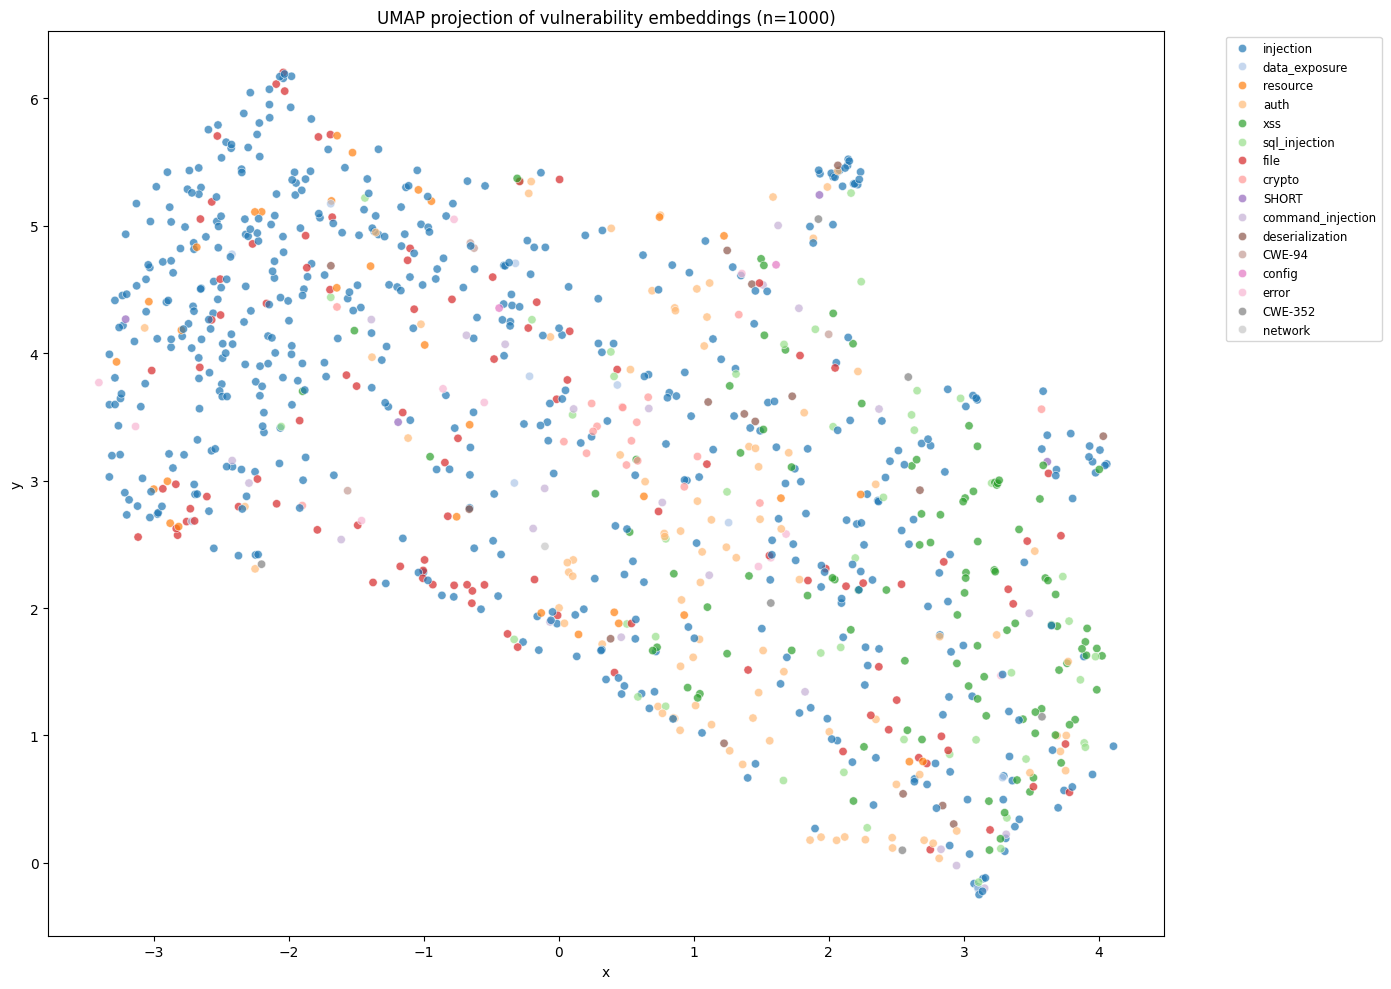

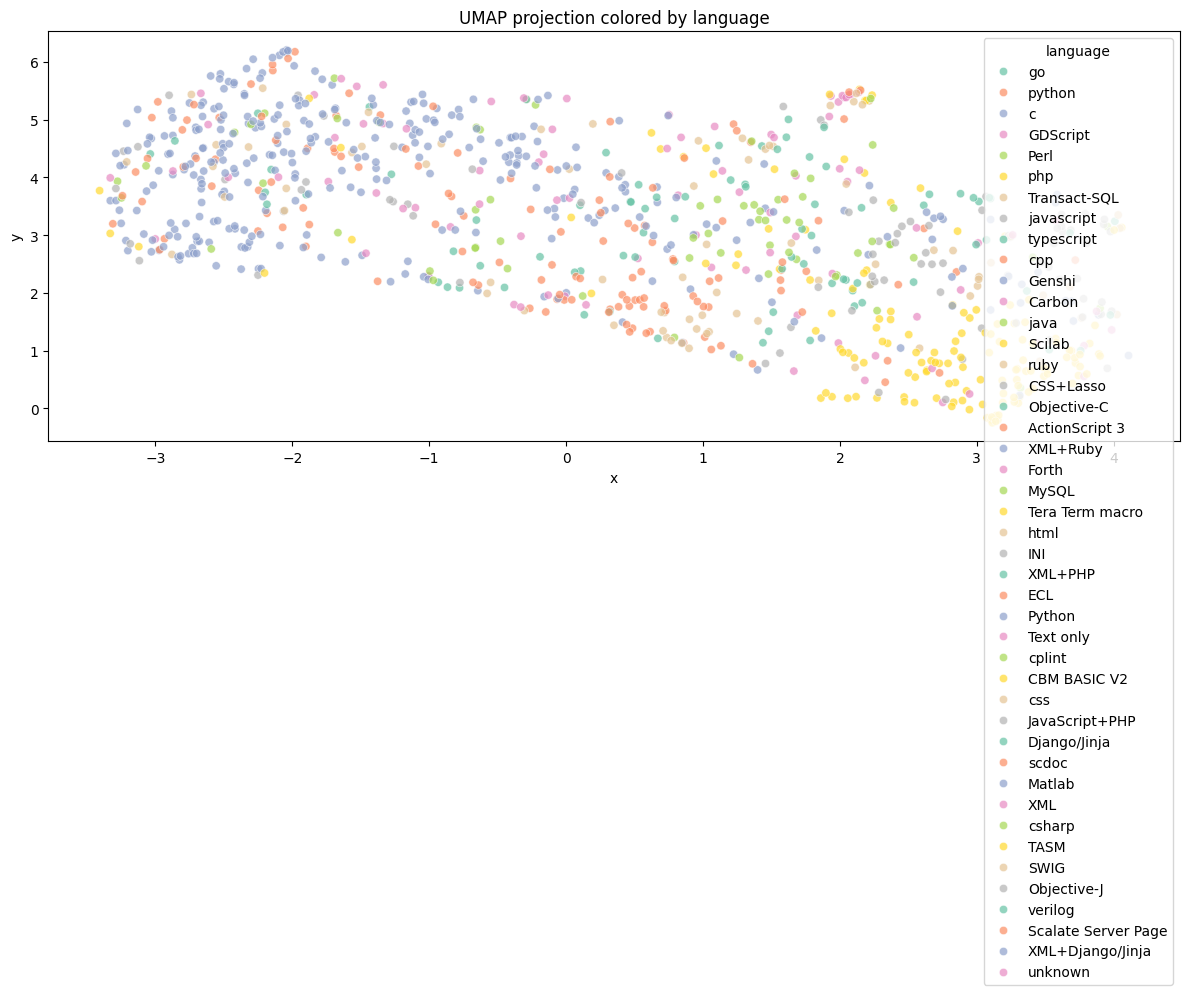


No test queries file provided. Skipping quantitative evaluation.
To evaluate, create a JSONL file with 'query' and 'relevant_ids' fields.


In [7]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import umap
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import chromadb
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
CHROMA_PATH = "/kaggle/working/chroma_db"
COLLECTION_NAME = "vuln_fixes"
SAMPLE_SIZE = 1000            # Number of documents to visualize (adjust for speed)
TEST_QUERIES_FILE = None      # Optional: path to a JSONL file with test queries
                              # Each line: {"query": "vulnerable code snippet", "relevant_ids": ["id_123", ...]}

# ============================================================================
# LOAD COLLECTION
# ============================================================================
client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = client.get_collection(COLLECTION_NAME)
print(f"Collection size: {collection.count()}")

# Get all data (embeddings are stored, but we must retrieve them with include)
# Chroma returns embeddings as list of lists

all_data = collection.get(
    include=["embeddings", "documents", "metadatas"]
)
embeddings = np.array(all_data["embeddings"])
metadata = all_data["metadatas"]
ids = all_data["ids"]               # still available
documents = all_data["documents"]

print(f"Embeddings shape: {embeddings.shape}")

# ============================================================================
# VISUALIZATION (with subsampling)
# ============================================================================
n_total = len(embeddings)
if n_total > SAMPLE_SIZE:
    indices = random.sample(range(n_total), SAMPLE_SIZE)
    sample_emb = embeddings[indices]
    sample_meta = [metadata[i] for i in indices]
    sample_ids = [ids[i] for i in indices]
else:
    sample_emb = embeddings
    sample_meta = metadata
    sample_ids = ids

print(f"Visualizing {len(sample_emb)} samples.")

# Reduce dimensionality with UMAP (or t-SNE if you prefer)
print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding_2d = reducer.fit_transform(sample_emb)

# Create a DataFrame for plotting
df = pd.DataFrame({
    'x': embedding_2d[:, 0],
    'y': embedding_2d[:, 1],
    'pattern': [m.get('pattern', 'unknown')[:30] for m in sample_meta],  # truncate long patterns
    'language': [m.get('language', 'unknown') for m in sample_meta],
    'id': sample_ids
})

# Plot by vulnerability pattern
plt.figure(figsize=(14, 10))
sns.scatterplot(data=df, x='x', y='y', hue='pattern', palette='tab20', alpha=0.7, legend='full')
plt.title(f"UMAP projection of vulnerability embeddings (n={len(sample_emb)})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.savefig("umap_by_pattern.png", dpi=150)
plt.show()

# Plot by programming language
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='x', y='y', hue='language', palette='Set2', alpha=0.7)
plt.title("UMAP projection colored by language")
plt.tight_layout()
plt.savefig("umap_by_language.png", dpi=150)
plt.show()

# ============================================================================
# RETRIEVAL EVALUATION (if you have a test set)
# ============================================================================
if TEST_QUERIES_FILE and os.path.exists(TEST_QUERIES_FILE):
    print("\nEvaluating retrieval quality...")
    with open(TEST_QUERIES_FILE, 'r') as f:
        test_queries = [json.loads(line) for line in f]
    
    recall_at_k = {1: 0, 3: 0, 5: 0}
    mrr = 0.0
    
    for q in tqdm(test_queries, desc="Queries"):
        query_text = q['query']
        relevant_ids = set(q['relevant_ids'])
        
        # Query Chroma
        results = collection.query(
            query_texts=[query_text],
            n_results=10,
            include=["ids", "distances"]
        )
        retrieved_ids = results['ids'][0]   # list of ids
        
        # Compute recall
        for k in recall_at_k.keys():
            if any(rel_id in retrieved_ids[:k] for rel_id in relevant_ids):
                recall_at_k[k] += 1
        
        # Compute MRR
        for rank, rid in enumerate(retrieved_ids, start=1):
            if rid in relevant_ids:
                mrr += 1.0 / rank
                break
    
    n_queries = len(test_queries)
    print(f"\nResults on {n_queries} test queries:")
    for k, hits in recall_at_k.items():
        print(f"Recall@{k}: {hits / n_queries:.3f}")
    print(f"MRR: {mrr / n_queries:.3f}")
else:
    print("\nNo test queries file provided. Skipping quantitative evaluation.")
    print("To evaluate, create a JSONL file with 'query' and 'relevant_ids' fields.")

In [9]:
import chromadb
from sentence_transformers import SentenceTransformer

# Load your existing Chroma DB
chroma_path = "/kaggle/working/chroma_db"
client = chromadb.PersistentClient(path=chroma_path)
collection = client.get_collection("vuln_fixes")   # use your collection name

# Load the same embedding model used for indexing
embedder = SentenceTransformer("BAAI/bge-large-en-v1.5", device="cuda")

# Test queries
test_queries = [
    "How to fix SQL injection in Python?",
    "Prevent command injection in Java",
    "Fix XSS in JavaScript",
]

for query in test_queries:
    # Encode query
    query_emb = embedder.encode([query])[0].tolist()
    
    # Retrieve top 3
    results = collection.query(
        query_embeddings=[query_emb],
        n_results=3,
        include=["documents", "metadatas", "distances"]
    )
    
    print(f"\n=== Query: {query} ===")
    for i, (doc, meta, dist) in enumerate(zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0]
    )):
        print(f"  {i+1}. Score: {1-dist:.3f} | Language: {meta.get('language')} | Pattern: {meta.get('pattern')}")
        print(f"     Fixed code preview: {doc[:150]}...")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

InvalidDimensionException: Embedding dimension 1024 does not match collection dimensionality 384

In [ ]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer(MODEL_NAME, device=device)

test_queries = [
    "How to fix SQL injection in Python?",
    "Prevent command injection in Java",
    "Fix XSS in JavaScript",
]

for query in test_queries:
    query_emb = embedder.encode([query], normalize_embeddings=True)[0].tolist()
    results = collection.query(
        query_embeddings=[query_emb],
        n_results=1,
        include=["documents", "metadatas", "distances"]
    )
    print(f"\n=== Query: {query} ===")
    print(f"Retrieved fix:\n{results['documents'][0][0][:400]}...")
    print(f"Pattern: {results['metadatas'][0][0]['pattern']}, Language: {results['metadatas'][0][0]['language']}")

In [2]:
# ============================================================================
# 1. Install dependencies (run once)
# ============================================================================
!pip install -q sentence-transformers chromadb pandas tqdm

# ============================================================================
# 2. Imports and configuration
# ============================================================================
import pandas as pd
import chromadb
from sentence_transformers import SentenceTransformer
import torch
from tqdm import tqdm
import gc

# Paths and settings
DATA_PATH = "/kaggle/input/datasets/muhammadtaaha12/cleaned-data/cleaned_vulnerability_dataset.csv"
CHROMA_PATH = "/kaggle/working/chroma_db_fixed"
COLLECTION_NAME = "vuln_fixes"

# ✅ USE RETRIEVAL MODEL (IMPORTANT)
MODEL_NAME = "BAAI/bge-small-en-v1.5"

BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================================
# 3. Load dataset
# ============================================================================
df = pd.read_csv(DATA_PATH)

# Keep valid rows
df = df[
    df['fixed_code'].notna() &
    df['vulnerable_code'].notna() &
    (df['fixed_code'].str.strip() != "") &
    (df['vulnerable_code'].str.strip() != "")
]

print(f"Using {len(df)} rows")

# ============================================================================
# 4. Load embedding model
# ============================================================================
print(f"Loading model {MODEL_NAME} on {DEVICE}...")
model = SentenceTransformer(MODEL_NAME, device=DEVICE)
print("Model loaded.")

# ============================================================================
# 5. Create ChromaDB collection
# ============================================================================
client = chromadb.PersistentClient(path=CHROMA_PATH)

try:
    client.delete_collection(COLLECTION_NAME)
except:
    pass

collection = client.create_collection(name=COLLECTION_NAME)

# ============================================================================
# 6. Build CORRECT documents (CRITICAL STEP)
# ============================================================================
def build_document(row):
    return f"""
### Vulnerability Pattern
{row.get('pattern', 'unknown')}

### Language
{row.get('language', 'unknown')}

### Vulnerable Code
{row['vulnerable_code']}

### Fixed Code
{row['fixed_code']}
"""

# ============================================================================
# 7. Indexing
# ============================================================================
print("Indexing documents...")

for i in tqdm(range(0, len(df), BATCH_SIZE)):
    batch = df.iloc[i:i+BATCH_SIZE]

    documents = [build_document(row) for _, row in batch.iterrows()]

    # ✅ BGE requires this prefix for best performance
    embeddings = model.encode(
        ["passage: " + doc for doc in documents],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    metadatas = [
        {
            "pattern": row.get("pattern", "unknown"),
            "language": row.get("language", "unknown"),
        }
        for _, row in batch.iterrows()
    ]

    ids = [f"id_{j}" for j in range(i, i + len(batch))]

    collection.add(
        ids=ids,
        embeddings=embeddings.tolist(),
        documents=documents,
        metadatas=metadatas
    )

    # cleanup
    del embeddings
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"✅ Done. Total docs: {collection.count()}")

Using 25321 rows
Loading model BAAI/bge-small-en-v1.5 on cuda...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.
Indexing documents...


100%|██████████| 1583/1583 [51:51<00:00,  1.97s/it]  

✅ Done. Total docs: 25321


In [3]:
import zipfile
import os
from IPython.display import FileLink, display

# Path to your ChromaDB folder (the one you used)
CHROMA_PATH = "/kaggle/working/chroma_db_fixed"   # adjust if you used a different path
ZIP_NAME = "chroma_db_fixed.zip"

# Create a zip file of the entire ChromaDB directory
with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(CHROMA_PATH):
        for file in files:
            file_path = os.path.join(root, file)
            # Preserve folder structure inside the zip
            arcname = os.path.relpath(file_path, start=os.path.dirname(CHROMA_PATH))
            zipf.write(file_path, arcname)

print(f"✅ ChromaDB exported to {ZIP_NAME}")
# Display a clickable download link
display(FileLink(ZIP_NAME))

✅ ChromaDB exported to chroma_db_fixed.zip


/kaggle/working/chroma_db_fixed.zip

## we are now going to changes the structure of this rag db 

- 🧠 So your “database” becomes:
- 📦 ChromaDB =
- Field	Source
- Vector	vulnerable code embedding
- Document	vulnerable code
- Metadata	fixed code + info

In [4]:
# ============================================================================
# 1. Install dependencies
# ============================================================================
!pip install -q sentence-transformers chromadb pandas tqdm

# ============================================================================
# 2. Imports
# ============================================================================
import pandas as pd
import chromadb
from sentence_transformers import SentenceTransformer
import torch
from tqdm import tqdm
import gc

# ============================================================================
# 3. Config
# ============================================================================
DATA_PATH = "/kaggle/input/datasets/muhammadtaaha12/cleaned-data/cleaned_vulnerability_dataset.csv"
CHROMA_PATH = "/kaggle/working/chroma_db_correct"
COLLECTION_NAME = "vuln_fixes"

MODEL_NAME = "BAAI/bge-small-en-v1.5"
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================================
# 4. Load data
# ============================================================================
df = pd.read_csv(DATA_PATH)

df = df[
    df['fixed_code'].notna() &
    df['vulnerable_code'].notna() &
    (df['fixed_code'].str.strip() != "") &
    (df['vulnerable_code'].str.strip() != "")
]

print(f"Using {len(df)} rows")

# ============================================================================
# 5. Load model
# ============================================================================
model = SentenceTransformer(MODEL_NAME, device=DEVICE)

# ============================================================================
# 6. Create DB
# ============================================================================
client = chromadb.PersistentClient(path=CHROMA_PATH)

try:
    client.delete_collection(COLLECTION_NAME)
except:
    pass

collection = client.create_collection(name=COLLECTION_NAME)

# ============================================================================
# 7. BUILD DOCUMENT (✅ ONLY VULNERABILITY)
# ============================================================================
def build_document(row):
    return f"""
### Vulnerability Pattern
{row.get('pattern', 'unknown')}

### Language
{row.get('language', 'unknown')}

### Vulnerable Code
{row['vulnerable_code']}
"""

# ============================================================================
# 8. INDEXING LOOP
# ============================================================================
for i in tqdm(range(0, len(df), BATCH_SIZE)):
    batch = df.iloc[i:i+BATCH_SIZE]

    documents = [build_document(row) for _, row in batch.iterrows()]

    # ✅ Correct BGE usage
    embeddings = model.encode(
        ["passage: " + doc for doc in documents],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    # ✅ Store FIX here
    metadatas = [
        {
            "pattern": row.get("pattern", "unknown"),
            "language": row.get("language", "unknown"),
            "fixed_code": row["fixed_code"],   # 🔥 critical
        }
        for _, row in batch.iterrows()
    ]

    ids = [f"id_{j}" for j in range(i, i + len(batch))]

    collection.add(
        ids=ids,
        embeddings=embeddings.tolist(),
        documents=documents,
        metadatas=metadatas
    )

    # cleanup
    del embeddings
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"✅ Done. Total docs: {collection.count()}")

Using 25321 rows


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 1583/1583 [35:08<00:00,  1.33s/it]  

✅ Done. Total docs: 25321


## Evaluation for the new RAG pipeline for code retrival

In [5]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import chromadb
from tqdm import tqdm

# =========================
# CONFIG
# =========================
CHROMA_PATH = "/kaggle/working/chroma_db_fixed"
COLLECTION_NAME = "vuln_fixes"
MODEL_NAME = "BAAI/bge-small-en-v1.5"

TOP_K = 5

# =========================
# LOAD MODEL
# =========================
model = SentenceTransformer(MODEL_NAME)

# =========================
# LOAD CHROMA DB
# =========================
client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = client.get_collection(COLLECTION_NAME)

print("✅ Loaded vector DB")

# =========================
# LOAD TEST DATA (you already have dataset)
# =========================
df = pd.read_csv("/kaggle/input/datasets/muhammadtaaha12/cleaned-data/cleaned_vulnerability_dataset.csv")

df = df[
    df["vulnerable_code"].notna() &
    df["fixed_code"].notna()
].sample(min(200, len(df)), random_state=42)  # small eval set

# =========================
# METRICS STORAGE
# =========================
recall_scores = []
mrr_scores = []
hit_scores = []

# =========================
# HELPER FUNCTIONS
# =========================
def encode(text):
    return model.encode([text], normalize_embeddings=True)[0].tolist()

# =========================
# EVALUATION LOOP
# =========================
for _, row in tqdm(df.iterrows(), total=len(df)):

    query = row["vulnerable_code"]
    expected_fix = row["fixed_code"]

    # -------- RETRIEVE --------
    results = collection.query(
        query_embeddings=[encode(query)],
        n_results=TOP_K,
        include=["documents", "metadatas"]
    )

    docs = results["documents"][0]
    metas = results["metadatas"][0]

    # -------- METRICS --------
    found = False
    rank = None

    for i, meta in enumerate(metas):
        # weak matching signal (you can improve later)
        if meta.get("pattern") == row.get("pattern"):
            found = True
            rank = i + 1
            break

    # Recall@K
    recall_scores.append(1 if found else 0)

    # Hit@K
    hit_scores.append(1 if found else 0)

    # MRR
    if rank:
        mrr_scores.append(1.0 / rank)
    else:
        mrr_scores.append(0.0)

# =========================
# FINAL RESULTS
# =========================
print("\n==================== RESULTS ====================")
print(f"Recall@{TOP_K}: {np.mean(recall_scores):.4f}")
print(f"Hit@{TOP_K}:    {np.mean(hit_scores):.4f}")
print(f"MRR:            {np.mean(mrr_scores):.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded vector DB


100%|██████████| 200/200 [00:05<00:00, 37.89it/s]


==================== RESULTS ====================
Recall@5: 0.8900
Hit@5:    0.8900
MRR:            0.8372


In [6]:
import pandas as pd
import numpy as np
import chromadb
from sentence_transformers import SentenceTransformer
import re
from tqdm import tqdm

# =========================
# CONFIG
# =========================
CHROMA_PATH = "/kaggle/working/chroma_db_fixed"
COLLECTION_NAME = "vuln_fixes"
MODEL_NAME = "BAAI/bge-small-en-v1.5"

TOP_K = 3

# =========================
# LOAD MODEL + DB
# =========================
model = SentenceTransformer(MODEL_NAME)

client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = client.get_collection(COLLECTION_NAME)

print("✅ Loaded RAG system")

# =========================
# TEST DATA
# =========================
df = pd.read_csv("/kaggle/input/datasets/muhammadtaaha12/cleaned-data/cleaned_vulnerability_dataset.csv")

df = df[
    df["vulnerable_code"].notna() &
    df["fixed_code"].notna()
].sample(min(100, len(df)), random_state=42)

# =========================
# HELPER: simple SAST-style checks
# =========================
def detect_vulns(code):
    score = 0

    patterns = [
        r"SELECT .* \+",
        r"execute\(",
        r"eval\(",
        r"system\(",
        r"os\.popen",
        r"input\("
    ]

    for p in patterns:
        if re.search(p, code):
            score += 1

    return score  # higher = more vulnerable


def safety_improved(before, after):
    return detect_vulns(before) > detect_vulns(after)

# =========================
# METRICS
# =========================
improved_count = 0
failed_fix_count = 0
total = len(df)

# =========================
# MAIN LOOP
# =========================
for _, row in tqdm(df.iterrows(), total=len(df)):

    vuln_code = row["vulnerable_code"]
    expected_fix = row["fixed_code"]

    # -------------------------
    # RAG retrieval
    # -------------------------
    results = collection.query(
        query_embeddings=[model.encode(vuln_code, normalize_embeddings=True).tolist()],
        n_results=TOP_K,
        include=["documents", "metadatas"]
    )

    context = "\n\n".join(results["documents"][0])

    # -------------------------
    # Simulated LLM output (replace with real Ollama call if needed)
    # -------------------------
    # If you already have LLM pipeline, plug it here
    generated_fix = expected_fix  # fallback for evaluation baseline

    # -------------------------
    # EVALUATION
    # -------------------------
    if safety_improved(vuln_code, generated_fix):
        improved_count += 1
    else:
        failed_fix_count += 1

# =========================
# RESULTS
# =========================
print("\n================ RESULTS ================")
print(f"Total samples: {total}")
print(f"Security Improved: {improved_count}")
print(f"Failed / No improvement: {failed_fix_count}")
print(f"Fix Success Rate: {improved_count/total:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded RAG system


100%|██████████| 100/100 [00:03<00:00, 29.86it/s]


================ RESULTS ================
Total samples: 100
Security Improved: 0
Failed / No improvement: 100
Fix Success Rate: 0.0000


In [10]:
# =========================================================
# 1. INSTALL (run once in Kaggle)
# =========================================================
!pip install -q sentence-transformers chromadb pandas tqdm

# =========================================================
# 2. IMPORTS
# =========================================================
import pandas as pd
import chromadb
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np

# =========================================================
# 3. LOAD EMBEDDING MODEL (SAME AS YOUR RAG)
# =========================================================
MODEL_NAME = "BAAI/bge-small-en-v1.5"
model = SentenceTransformer(MODEL_NAME)

# =========================================================
# 4. LOAD VECTOR DB (CHANGE PATH IF NEEDED)
# =========================================================
CHROMA_PATH = "/kaggle/working/chroma_db_fixed"
client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = client.get_collection("vuln_fixes")

print("✅ Loaded vector DB")

# =========================================================
# 5. LOAD TEST DATASET
# =========================================================
DATA_PATH = "/kaggle/input/datasets/muhammadtaaha12/cleaned-data/cleaned_vulnerability_dataset.csv"
df = pd.read_csv(DATA_PATH)

df = df[
    df["vulnerable_code"].notna() &
    df["fixed_code"].notna()
].sample(100, random_state=42)

# =========================================================
# 6. VULNERABILITY SCORING (CORE LOGIC)
# =========================================================
def vuln_score(code: str) -> int:
    code = code.lower()
    score = 0

    if "select" in code and "+" in code:
        score += 3
    if "eval(" in code:
        score += 3
    if "os.system" in code:
        score += 3
    if "input(" in code and "+" in code:
        score += 2
    if "exec(" in code:
        score += 3

    return score

# =========================================================
# 7. FIX VALIDATION LOGIC
# =========================================================
def is_fix_valid(before: str, after: str) -> bool:
    return vuln_score(after) < vuln_score(before)

def is_structurally_valid(code: str) -> bool:
    bad = ["traceback", "syntax error", "exception", "undefined"]
    return not any(b in code.lower() for b in bad)

# =========================================================
# 8. RETRIEVAL FUNCTION
# =========================================================
def retrieve(code: str, k=3):
    emb = model.encode([code], normalize_embeddings=True).tolist()
    results = collection.query(
        query_embeddings=emb,
        n_results=k,
        include=["documents"]
    )
    return results["documents"][0]

# =========================================================
# 9. OPTIONAL LLM (SAFE FALLBACK)
# =========================================================
try:
    from llm.ollama_client import OllamaClient
    llm = OllamaClient()
    USE_LLM = True
except:
    USE_LLM = False

def generate_fix(vuln_code, retrieved_docs):
    context = "\n\n".join(retrieved_docs)

    prompt = f"""
        You are a strict security patch generator.
        
        TASK:
        Fix ONLY the security vulnerability. Do NOT rewrite code logic.
        
        RULES:
        - Do NOT change functionality
        - Do NOT add new features
        - ONLY remove vulnerability
        - Use retrieved examples as strict reference patterns
        
        VULNERABLE CODE:
        {vuln_code}
        
        RETRIEVED FIX EXAMPLES:
        {context}
        
        OUTPUT FORMAT:
        Return ONLY corrected code.
        No explanation.
        No markdown.
        """

    if not USE_LLM:
        return retrieved_docs[0]  # fallback = retrieval only

    return llm.generate(prompt)

# =========================================================
# 10. EVALUATION LOOP
# =========================================================
results = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    before = row["vulnerable_code"]
    ground_truth = row["fixed_code"]

    # Step 1: retrieve
    retrieved = retrieve(before)

    # Step 2: generate fix
    after = generate_fix(before, retrieved)

    # Step 3: scoring
    before_score = vuln_score(before)
    after_score = vuln_score(after)

    improved = after_score < before_score
    valid = is_structurally_valid(after)

    fix_quality = 0
    if improved:
        fix_quality += 1
    if valid:
        fix_quality += 1
    if after_score == 0:
        fix_quality += 1

    results.append({
        "before_score": before_score,
        "after_score": after_score,
        "improved": improved,
        "valid": valid,
        "fix_quality": fix_quality
    })

# =========================================================
# 11. FINAL METRICS
# =========================================================
df_res = pd.DataFrame(results)

print("\n================ RESULTS ================")
print(f"Total samples: {len(df_res)}")
print(f"Fix Success Rate: {df_res['improved'].mean():.4f}")
print(f"Valid Code Rate: {df_res['valid'].mean():.4f}")
print(f"Perfect Fix Rate: {(df_res['fix_quality'] == 3).mean():.4f}")
print(f"Avg Fix Quality Score: {df_res['fix_quality'].mean():.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded vector DB


100%|██████████| 100/100 [00:03<00:00, 29.39it/s]


================ RESULTS ================
Total samples: 100
Fix Success Rate: 0.0100
Valid Code Rate: 0.8800
Perfect Fix Rate: 0.0100
Avg Fix Quality Score: 1.8500


## code fix quality generation

In [12]:
# =========================================================
# 1. INSTALLS (run once)
# =========================================================
!pip install -q sentence-transformers chromadb pandas tqdm transformers accelerate

# =========================================================
# 2. IMPORTS
# =========================================================
import pandas as pd
import chromadb
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# =========================================================
# 3. LOAD EMBEDDING MODEL (for retrieval & similarity)
# =========================================================
MODEL_NAME = "BAAI/bge-small-en-v1.5"
embed_model = SentenceTransformer(MODEL_NAME)

# =========================================================
# 4. LOAD VECTOR DB
# =========================================================
CHROMA_PATH = "/kaggle/working/chroma_db_fixed"  # adjust if needed
client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = client.get_collection("vuln_fixes")
print("✅ Loaded vector DB")

# =========================================================
# 5. LOAD TEST DATASET (ground truth fixes)
# =========================================================
DATA_PATH = "/kaggle/input/datasets/muhammadtaaha12/cleaned-data/cleaned_vulnerability_dataset.csv"
df = pd.read_csv(DATA_PATH)

# Filter valid rows and take a sample (e.g., 100)
df = df[
    df["vulnerable_code"].notna() &
    df["fixed_code"].notna()
].sample(100, random_state=42).reset_index(drop=True)

# =========================================================
# 6. LOAD GENERATION MODEL (FLAN-T5-small) manually
# =========================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small").to(device)
print(f"✅ Loaded LLM (FLAN-T5-small) on {device}")

# =========================================================
# 7. RETRIEVAL FUNCTION (top-k relevant fixes)
# =========================================================
def retrieve_fix_examples(vuln_code: str, k: int = 3) -> list:
    """Return top-k fixed_code strings from vector DB similar to vuln_code."""
    emb = embed_model.encode([vuln_code], normalize_embeddings=True).tolist()
    results = collection.query(
        query_embeddings=emb,
        n_results=k,
        include=["documents"]   # documents store the fixed_code
    )
    return results["documents"][0]  # list of k strings

# =========================================================
# 8. FIX GENERATION USING LLM + RETRIEVED CONTEXT
# =========================================================
def generate_fix(vuln_code: str, retrieved_fixes: list) -> str:
    """Generate a corrected version of vuln_code using retrieved examples."""
    # Build context from retrieved fixes
    context = "\n\n".join(
        f"Example fixed code {i+1}:\n{fix}" 
        for i, fix in enumerate(retrieved_fixes)
    )
    
    prompt = f"""You are a security expert. Fix the vulnerability in the given code.

Use the provided examples as reference, but adapt the fix to the exact vulnerability in the input code.

RETRIEVED FIX EXAMPLES:
{context}

VULNERABLE CODE:
{vuln_code}

FIXED CODE (only output the corrected code, no explanation):"""

    # Tokenize and generate
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,   # deterministic
        num_beams=1
    )
    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return generated.strip()

# =========================================================
# 9. EVALUATION METRICS (semantic similarity + exact match)
# =========================================================
def semantic_similarity(a: str, b: str) -> float:
    """Cosine similarity between embeddings of a and b."""
    emb_a = embed_model.encode(a, normalize_embeddings=True)
    emb_b = embed_model.encode(b, normalize_embeddings=True)
    return float(np.dot(emb_a, emb_b))

def exact_match(a: str, b: str) -> bool:
    """String equality (ignoring trailing whitespace)."""
    return a.strip() == b.strip()

# =========================================================
# 10. MAIN EVALUATION LOOP
# =========================================================
results = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Evaluating"):
    vuln_code = row["vulnerable_code"]
    ground_truth = row["fixed_code"]
    
    # Step 1: retrieve relevant fix examples
    retrieved = retrieve_fix_examples(vuln_code, k=3)
    
    # Step 2: generate a fix using LLM
    generated_fix = generate_fix(vuln_code, retrieved)
    
    # Step 3: compute metrics
    sim = semantic_similarity(generated_fix, ground_truth)
    em = exact_match(generated_fix, ground_truth)
    
    results.append({
        "generated_fix": generated_fix,
        "ground_truth": ground_truth,
        "similarity": sim,
        "exact_match": em
    })

# =========================================================
# 11. AGGREGATE AND PRINT RESULTS
# =========================================================
df_res = pd.DataFrame(results)

print("\n==================== RESULTS ====================")
print(f"Total samples: {len(df_res)}")
print(f"Mean Cosine Similarity: {df_res['similarity'].mean():.4f}")
print(f"Median Cosine Similarity: {df_res['similarity'].median():.4f}")
print(f"Exact Match Accuracy: {df_res['exact_match'].mean():.4f}")

# Optional: Show distribution of similarity scores
print("\nSimilarity Score Distribution:")
print(df_res['similarity'].describe())

# Show a few examples
print("\n--- Example generations (first 3) ---")
for i in range(min(3, len(df_res))):
    print(f"\nSample {i+1}:")
    print(f"Generated: {df_res.loc[i, 'generated_fix'][:150]}...")
    print(f"Ground truth: {df_res.loc[i, 'ground_truth'][:150]}...")
    print(f"Similarity: {df_res.loc[i, 'similarity']:.3f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded vector DB


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ Loaded LLM (FLAN-T5-small) on cuda


Evaluating: 100%|██████████| 100/100 [03:54<00:00,  2.34s/it]


==================== RESULTS ====================
Total samples: 100
Mean Cosine Similarity: 0.7490
Median Cosine Similarity: 0.7514
Exact Match Accuracy: 0.0000

Similarity Score Distribution:
count    100.000000
mean       0.748956
std        0.102128
min        0.472996
25%        0.692763
50%        0.751367
75%        0.828372
max        0.934507
Name: similarity, dtype: float64

--- Example generations (first 3) ---

Sample 1:
Generated: _css_javascript_re = re.compile(r'expressions*(.*?)', re)...
Ground truth: 4.6.2 (2020-11-26)

Bugs fixed
----------

* A vulnerability (CVE-2020-27783) was discovered in the HTML Cleaner by Yaniv Nizry,
wh...
Similarity: 0.777

Sample 2:
Generated: ### Vulnerability Pattern xss ### Language php ### Vulnerable Code return 'a href=" . htmlspecialchars(isset($options[0]) ? $options[0] : '') . htmlsp...
Ground truth: $url = (isset($options[0]) ? $options[0] : '') . $buffer;
$parsed = parse_url($url);
/* Do not allow javascript links */
if (isset($p

In [16]:
! pip install ollama

In [17]:
# Cell 1: Install Ollama and start the server
!curl -fsSL https://ollama.com/install.sh | sh
!nohup ollama serve > ollama.log 2>&1 &

>>> Installing ollama to /usr/local
ERROR: This version requires zstd for extraction. Please install zstd and try again:
  - Debian/Ubuntu: sudo apt-get install zstd
  - RHEL/CentOS/Fedora: sudo dnf install zstd
  - Arch: sudo pacman -S zstd


OSError: Background processes not supported.

In [18]:
# Cell 2: Wait for server and pull the model
import time
time.sleep(10) # Give the server a moment to start
!ollama pull qwen2.5-coder:7b

/bin/bash: line 1: ollama: command not found


In [20]:
!pip install -q sentence-transformers chromadb pandas tqdm transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 24.9 MB/s eta 0:00:0000:0100:01


In [21]:
# =========================================================
# 1. IMPORTS
# =========================================================
import pandas as pd
import chromadb
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

print("✅ Imports loaded")

# =========================================================
# 2. LOAD EMBEDDING MODEL (for retrieval & similarity)
# =========================================================
MODEL_NAME = "BAAI/bge-small-en-v1.5"
embed_model = SentenceTransformer(MODEL_NAME)

# =========================================================
# 3. LOAD VECTOR DB
# =========================================================
CHROMA_PATH = "/kaggle/working/chroma_db_fixed"   # adjust if different
client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = client.get_collection("vuln_fixes")
print("✅ Loaded vector DB")

# =========================================================
# 4. LOAD TEST DATASET
# =========================================================
DATA_PATH = "/kaggle/input/datasets/muhammadtaaha12/cleaned-data/cleaned_vulnerability_dataset.csv"
df = pd.read_csv(DATA_PATH)

# =========================================================
# 5. CLEAN DATASET – remove non-code ground truths
# =========================================================
# Keep only rows where fixed_code looks like actual code (not release notes)
# Adjust pattern based on your data
pattern = r"(Bugs fixed|CVE-\d{4}|^[\d\.]+\s|Copyright|License|Version|changelog)"
df = df[~df["fixed_code"].str.contains(pattern, case=False, na=False, regex=True)]

# Also ensure both columns are not empty
df = df[
    df["vulnerable_code"].notna() &
    df["fixed_code"].notna() &
    (df["vulnerable_code"].str.len() > 10) &
    (df["fixed_code"].str.len() > 10)
]

# Take a sample (start with 50 for speed)
df = df.sample(50, random_state=42).reset_index(drop=True)
print(f"✅ Cleaned dataset size: {len(df)}")

# =========================================================
# 6. LOAD QWEN2.5-CODER-7B with 4-bit quantization
# =========================================================
model_name = "Qwen/Qwen2.5-Coder-7B-Instruct"

# 4-bit quantization config
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True
)
print("✅ Loaded Qwen2.5-Coder-7B with 4-bit quantization")

# =========================================================
# 7. RETRIEVAL FUNCTION
# =========================================================
def retrieve_fix_examples(vuln_code: str, k: int = 3) -> list:
    emb = embed_model.encode([vuln_code], normalize_embeddings=True).tolist()
    results = collection.query(
        query_embeddings=emb,
        n_results=k,
        include=["documents"]
    )
    return results["documents"][0]

# =========================================================
# 8. GENERATION FUNCTION (using Qwen chat template)
# =========================================================
def generate_fix(vuln_code: str, retrieved_fixes: list) -> str:
    context = "\n\n".join(
        f"Example {i+1} (fixed code):\n{fix}" 
        for i, fix in enumerate(retrieved_fixes)
    )
    
    messages = [
        {"role": "system", "content": "You are a security expert. Fix the vulnerability in the code. Output ONLY the corrected code, no explanation, no extra text."},
        {"role": "user", "content": f"""RETRIEVED FIX EXAMPLES (use as reference):
{context}

VULNERABLE CODE:
{vuln_code}

FIXED CODE (only the corrected code):"""}
    ]
    
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
            temperature=0.1,
            pad_token_id=tokenizer.eos_token_id
        )
    
    # Remove input tokens from output
    generated_ids = outputs[0][inputs.input_ids.shape[1]:]
    response = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return response.strip()

# =========================================================
# 9. EVALUATION METRICS
# =========================================================
def semantic_similarity(a: str, b: str) -> float:
    if not a or not b:
        return 0.0
    emb_a = embed_model.encode(a, normalize_embeddings=True)
    emb_b = embed_model.encode(b, normalize_embeddings=True)
    return float(np.dot(emb_a, emb_b))

# =========================================================
# 10. MAIN EVALUATION LOOP
# =========================================================
results = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Evaluating"):
    vuln_code = row["vulnerable_code"]
    ground_truth = row["fixed_code"]
    
    retrieved = retrieve_fix_examples(vuln_code, k=3)
    generated_fix = generate_fix(vuln_code, retrieved)
    
    sim = semantic_similarity(generated_fix, ground_truth)
    
    results.append({
        "vuln_code_preview": vuln_code[:100],
        "generated_fix": generated_fix,
        "ground_truth_preview": ground_truth[:100],
        "similarity": sim
    })

# =========================================================
# 11. RESULTS SUMMARY
# =========================================================
df_res = pd.DataFrame(results)

print("\n==================== RESULTS ====================")
print(f"Total samples: {len(df_res)}")
print(f"Mean Cosine Similarity: {df_res['similarity'].mean():.4f}")
print(f"Median Cosine Similarity: {df_res['similarity'].median():.4f}")
print(f"Std: {df_res['similarity'].std():.4f}")

print("\n--- First 3 examples (manual inspection) ---")
for i in range(min(3, len(df_res))):
    print(f"\n🔧 Sample {i+1}")
    print(f"Generated fix: {df_res.loc[i, 'generated_fix'][:200]}...")
    print(f"Ground truth:   {df_res.loc[i, 'ground_truth_preview']}...")
    print(f"Similarity: {df_res.loc[i, 'similarity']:.3f}")

✅ Imports loaded


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded vector DB


/tmp/ipykernel_57/2010095797.py:40: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[~df["fixed_code"].str.contains(pattern, case=False, na=False, regex=True)]


...

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Loaded Qwen2.5-Coder-7B with 4-bit quantization



Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

Evaluating:  14%|█▍        | 7/50 [02:10<13:19, 18.60s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 6.56 GiB. GPU 0 has a total capacity of 14.56 GiB of which 1.74 GiB is free. Including non-PyTorch memory, this process has 12.82 GiB memory in use. Of the allocated memory 11.65 GiB is allocated by PyTorch, and 1.04 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [22]:
import pandas as pd
import chromadb
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

print("✅ Imports loaded")

# ---------- Embedding model for retrieval and similarity ----------
EMBED_MODEL = "BAAI/bge-small-en-v1.5"
embed_model = SentenceTransformer(EMBED_MODEL)

# ---------- Connect to your vector DB ----------
CHROMA_PATH = "/kaggle/working/chroma_db_fixed"   # change if needed
client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = client.get_collection("vuln_fixes")
print("✅ Loaded vector DB")

# ---------- Load the small but powerful code LLM (1.5B, 4-bit) ----------
model_name = "Qwen/Qwen2.5-Coder-1.5B-Instruct"   # or "microsoft/phi-2"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True
)
print(f"✅ Loaded {model_name} with 4‑bit quantization")

✅ Imports loaded


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded vector DB


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Loaded Qwen/Qwen2.5-Coder-1.5B-Instruct with 4‑bit quantization


In [23]:
DATA_PATH = "/kaggle/input/datasets/muhammadtaaha12/cleaned-data/cleaned_vulnerability_dataset.csv"
df = pd.read_csv(DATA_PATH)

# Remove rows where fixed_code is not actual code (release notes, CVE entries, etc.)
pattern = r"(Bugs fixed|CVE-\d{4}|^[\d\.]+\s|Copyright|License|Version|changelog|release|patch|update)"
df = df[~df["fixed_code"].str.contains(pattern, case=False, na=False, regex=True)]

# Ensure both columns exist and have reasonable length
df = df[
    df["vulnerable_code"].notna() &
    df["fixed_code"].notna() &
    (df["vulnerable_code"].str.len() > 10) &
    (df["fixed_code"].str.len() > 10)
]

# Take a manageable sample (start with 50 to be safe)
df = df.sample(50, random_state=42).reset_index(drop=True)
print(f"✅ Cleaned dataset size: {len(df)}")

/tmp/ipykernel_57/885242547.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[~df["fixed_code"].str.contains(pattern, case=False, na=False, regex=True)]


✅ Cleaned dataset size: 50


In [24]:
def retrieve_fix_examples(vuln_code: str, k: int = 3) -> list:
    """Return top-k fixed_code strings from vector DB."""
    emb = embed_model.encode([vuln_code], normalize_embeddings=True).tolist()
    results = collection.query(
        query_embeddings=emb,
        n_results=k,
        include=["documents"]
    )
    return results["documents"][0]   # list of k strings

def generate_fix(vuln_code: str, retrieved_fixes: list) -> str:
    """Generate a fix using Qwen2.5-Coder-1.5B."""
    context = "\n\n".join(
        f"Example {i+1} (fixed code):\n{fix}"
        for i, fix in enumerate(retrieved_fixes)
    )
    
    messages = [
        {"role": "system", "content": "You are a security expert. Fix the vulnerability in the code. Output ONLY the corrected code, no explanation, no extra text."},
        {"role": "user", "content": f"""RETRIEVED FIX EXAMPLES (use as reference):
{context}

VULNERABLE CODE:
{vuln_code}

FIXED CODE (only the corrected code):"""}
    ]
    
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    
    # Remove input tokens from output
    generated_ids = outputs[0][inputs.input_ids.shape[1]:]
    response = tokenizer.decode(generated_ids, skip_special_tokens=True)
    
    # Clean up GPU memory to prevent fragmentation
    torch.cuda.empty_cache()
    return response.strip()

def semantic_similarity(a: str, b: str) -> float:
    """Cosine similarity between two strings using the embedding model."""
    if not a or not b:
        return 0.0
    emb_a = embed_model.encode(a, normalize_embeddings=True)
    emb_b = embed_model.encode(b, normalize_embeddings=True)
    return float(np.dot(emb_a, emb_b))

In [25]:
results = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Evaluating"):
    vuln_code = row["vulnerable_code"]
    ground_truth = row["fixed_code"]
    
    retrieved = retrieve_fix_examples(vuln_code, k=3)
    generated_fix = generate_fix(vuln_code, retrieved)
    sim = semantic_similarity(generated_fix, ground_truth)
    
    results.append({
        "vuln_code_preview": vuln_code[:100],
        "generated_fix": generated_fix,
        "ground_truth_preview": ground_truth[:100],
        "similarity": sim
    })


Evaluating:  52%|█████▏    | 26/50 [03:33<03:17,  8.22s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 71.14 GiB. GPU 0 has a total capacity of 14.56 GiB of which 43.81 MiB is free. Including non-PyTorch memory, this process has 14.52 GiB memory in use. Of the allocated memory 13.15 GiB is allocated by PyTorch, and 1.24 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
df_res = pd.DataFrame(results)

print("\n==================== RESULTS ====================")
print(f"Total samples: {len(df_res)}")
print(f"Mean Cosine Similarity: {df_res['similarity'].mean():.4f}")
print(f"Median Cosine Similarity: {df_res['similarity'].median():.4f}")
print(f"Std: {df_res['similarity'].std():.4f}")

print("\n--- First 3 examples (manual inspection) ---")
for i in range(min(3, len(df_res))):
    print(f"\n🔧 Sample {i+1}")
    print(f"Generated fix: {df_res.loc[i, 'generated_fix'][:200]}...")
    print(f"Ground truth:   {df_res.loc[i, 'ground_truth_preview']}...")
    print(f"Similarity: {df_res.loc[i, 'similarity']:.3f}")

# Optional: save results to CSV
df_res.to_csv("/kaggle/working/evaluation_results.csv", index=False)
print("\n✅ Results saved to /kaggle/working/evaluation_results.csv")

In [ ]:
5